# Do SAE Features Encode Vulnerability Mechanisms or Language Patterns?

**Research question:** The top-ranked SAE features (by Fisher discriminant score on the DeltaSecommits dataset) fire strongly on specific CWE families — Feature 438 on injection CWEs, Feature 1797 on memory CWEs. But is this because the model learned *vulnerability mechanisms*, or because it learned *programming language syntax* that co-occurs with those CWEs?

**Dataset confound:** In DeltaSecommits, CWE families are near-perfectly correlated with language:
- Memory CWEs (CWE-119, -125, -787, -416, -401, -190, -476) → ~97 % C/C++ code
- Injection CWEs (CWE-89, -79, -94, -78) → ~73 % PHP, ~16 % JS code

This makes raw activation patterns ambiguous. We apply four controlled tests to disentangle the two hypotheses.

---

| Test | Holds constant | Varies | Prediction under *language* hypothesis |
|---|---|---|---|
| A. Cross-language within CWE | CWE type | Language | Large activation gap between languages |
| B. Within-language across CWE | Language | CWE type | No activation gap between CWE families |
| C. GLM decomposition | — | Both | Language AUC ≈ Language+CWE AUC |
| D. Language-residualized CWE signal | Language mean | CWE | Residual ≈ 0, no family pattern |

In [34]:
%load_ext autoreload
%autoreload 2

import glob, warnings
import orjson
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm.auto import tqdm
from scipy.stats import mannwhitneyu, kruskal
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import OneHotEncoder

warnings.filterwarnings("ignore")

# ── Publication style ────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "font.family": "sans-serif",
})
sns.set_style("whitegrid")

# ── Colour palette ───────────────────────────────────────────────────────────
COL_MEM  = "#d62728"   # red    — memory CWEs / C-family
COL_INJ  = "#ff7f0e"   # orange — injection CWEs / PHP/JS
COL_OTH  = "#1f77b4"   # blue   — other CWEs / other languages
COL_GRAY = "#aaaaaa"   # gray   — raw/baseline

print("Setup complete.")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Setup complete.


In [35]:
# ── CONFIG ────────────────────────────────────────────────────────────────────
FEATURES  = [438, 1797]
LAYER     = 11
RUN_ID    = "run_20260218_134529_vulnerable_code_qwen_coder_standard_16384_10M"
EPSILON   = 1e-6

MEMORY_CWES    = {"CWE-119", "CWE-125", "CWE-787", "CWE-416", "CWE-401",
                  "CWE-190", "CWE-476", "CWE-120", "CWE-189", "CWE-415", "CWE-369"}
INJECTION_CWES = {"CWE-89",  "CWE-79",  "CWE-94",  "CWE-78",  "CWE-352", "CWE-434"}
C_FAMILY       = {"c", "cc", "cpp", "h", "cxx"}
PHP_JS_FAMILY  = {"php", "js", "ts"}
# ─────────────────────────────────────────────────────────────────────────────

files = sorted(glob.glob(
    f"../../artifacts/activations/{RUN_ID}/activations_layer_{LAYER}_*.jsonl"
))
assert files, "No activation files found — check RUN_ID and LAYER."

records = []
with open(files[0]) as fh:
    for line in tqdm(fh, desc="Loading"):
        d   = orjson.loads(line)
        ext = d["file_extension"].lower().lstrip(".")
        cwe = d["cwe"]
        fam = ("memory"    if cwe in MEMORY_CWES
               else "injection" if cwe in INJECTION_CWES
               else "other")
        base = dict(vuln_id=d["vuln_id"], cwe=cwe, lang=ext, cwe_family=fam,
                    is_c=ext in C_FAMILY, is_php_js=ext in PHP_JS_FAMILY)
        for lbl_key, lbl in [("secure", 0), ("vulnerable", 1)]:
            row = {**base, "label": lbl}
            for feat in FEATURES:
                row[f"f{feat}_val"]    = d[lbl_key][feat]
                row[f"f{feat}_active"] = int(d[lbl_key][feat] > EPSILON)
            records.append(row)

df = pd.DataFrame(records)

# language-residualized columns
for feat in FEATURES:
    lang_mean = df.groupby("lang")[f"f{feat}_val"].transform("mean")
    df[f"f{feat}_resid"] = df[f"f{feat}_val"] - lang_mean

print(f"Rows loaded: {len(df):,}  ({len(df)//2:,} unique code snippets, both labels)")
print()

# Dataset confound summary
dist = (df.drop_duplicates(subset=["vuln_id", "label"])
          .groupby(["cwe_family", "is_c"])["vuln_id"].count()
          .unstack()
          .rename(columns={False: "non-C", True: "C-family"}))
dist["total"]   = dist.sum(axis=1)
dist["%C"]      = (dist.get("C-family", 0) / dist["total"] * 100).round(1)
dist["%non-C"]  = (dist.get("non-C",    0) / dist["total"] * 100).round(1)
print("Dataset distribution (unique snippets):")
print(dist.to_string())

Loading: 0it [00:00, ?it/s]

Rows loaded: 4,986  (2,493 unique code snippets, both labels)

Dataset distribution (unique snippets):
is_c        non-C  C-family  total    %C  %non-C
cwe_family                                      
injection    1168        22   1190   1.8    98.2
memory         30      2292   2322  98.7     1.3
other         512       774   1286  60.2    39.8


---
## 1  The Observation: Features appear to be CWE-domain detectors

The naïve view: plot `P(feature active | CWE)` alongside `P(feature active | language)`.  
If the two bar charts look nearly identical, the CWE signal is explained by language.

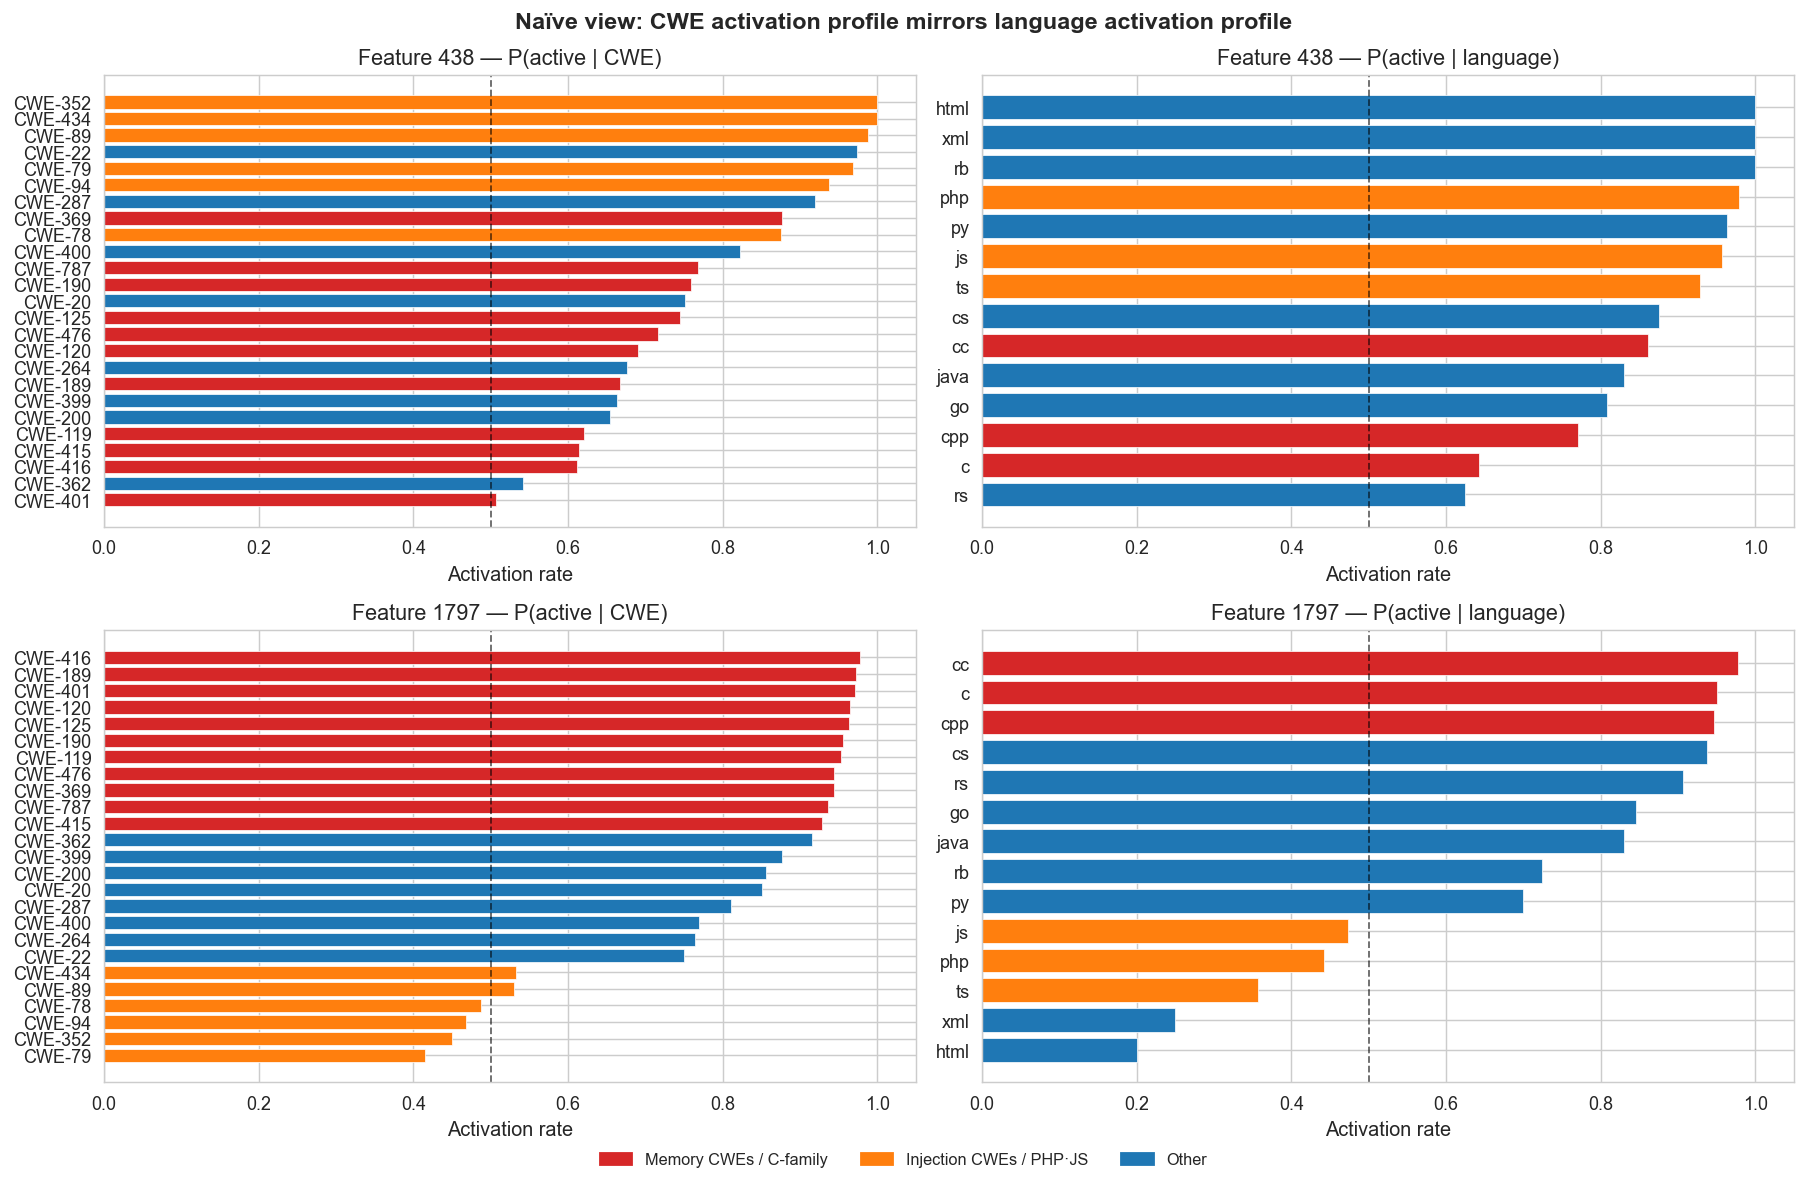

Activation lift comparison:
   Feature     CWE-family lift    Language lift    Ratio lang/CWE
-----------------------------------------------------------------
  F  438              +0.258           +0.278              1.08x
  F 1797              +0.305           +0.441              1.45x


In [36]:
def _bar_color(name, lookup_mem, lookup_inj):
    if name in lookup_mem: return COL_MEM
    if name in lookup_inj: return COL_INJ
    return COL_OTH

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for row_i, feat in enumerate(FEATURES):
    act_col = f"f{feat}_active"

    by_cwe  = df.groupby("cwe")[act_col].mean().sort_values(ascending=False)
    by_lang = df.groupby("lang")[act_col].mean().sort_values(ascending=False)

    # P(active | CWE)
    ax = axes[row_i][0]
    colors = [_bar_color(c, MEMORY_CWES, INJECTION_CWES) for c in by_cwe.index]
    ax.barh(by_cwe.index, by_cwe.values, color=colors, edgecolor="white", linewidth=0.4)
    ax.axvline(0.5, color="black", linestyle="--", lw=1, alpha=0.6)
    ax.set_xlabel("Activation rate")
    ax.set_title(f"Feature {feat} — P(active | CWE)")
    ax.invert_yaxis()
    ax.set_xlim(0, 1.05)

    # P(active | language)
    ax = axes[row_i][1]
    colors = [COL_MEM if l in C_FAMILY else COL_INJ if l in PHP_JS_FAMILY else COL_OTH
              for l in by_lang.index]
    ax.barh(by_lang.index, by_lang.values, color=colors, edgecolor="white", linewidth=0.4)
    ax.axvline(0.5, color="black", linestyle="--", lw=1, alpha=0.6)
    ax.set_xlabel("Activation rate")
    ax.set_title(f"Feature {feat} — P(active | language)")
    ax.invert_yaxis()
    ax.set_xlim(0, 1.05)

# Shared legend
legend_patches = [
    mpatches.Patch(color=COL_MEM, label="Memory CWEs / C-family"),
    mpatches.Patch(color=COL_INJ, label="Injection CWEs / PHP·JS"),
    mpatches.Patch(color=COL_OTH, label="Other"),
]
fig.legend(handles=legend_patches, loc="lower center", ncol=3,
           bbox_to_anchor=(0.5, -0.02), frameon=False)

fig.suptitle("Naïve view: CWE activation profile mirrors language activation profile",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("narrative_fig1_naive_activation.png", dpi=150, bbox_inches="tight")
plt.show()

# Quantify the mirroring
print("Activation lift comparison:")
print(f"{'Feature':>10}  {'CWE-family lift':>18}  {'Language lift':>15}  {'Ratio lang/CWE':>16}")
print("-" * 65)
for feat, dom_fam, dom_lang in [(438, "injection", PHP_JS_FAMILY),
                                 (1797, "memory",    C_FAMILY)]:
    act = f"f{feat}_active"
    fam_lift  = df[df["cwe_family"]==dom_fam][act].mean() - df[df["cwe_family"]!=dom_fam][act].mean()
    lang_lift = df[df["lang"].isin(dom_lang)][act].mean() - df[~df["lang"].isin(dom_lang)][act].mean()
    print(f"  F{feat:>5}  {fam_lift:>+18.3f}  {lang_lift:>+15.3f}  {lang_lift/fam_lift:>16.2f}x")

**Finding 1:** The activation lift attributed to CWE family is almost entirely matched by an equal or larger lift attributed to language alone. The ratio of language lift to CWE lift is >1× for both features, so language is a sufficient explanation for the naïve signal.

---
## 2  Test A — Cross-language within CWE: Is language driving the signal?

Hold CWE type fixed, vary language. If the feature is a true mechanism detector, PHP and C code with *the same injection CWE* should activate Feature 438 equally. If it is a language detector, PHP >> C within injection CWEs.

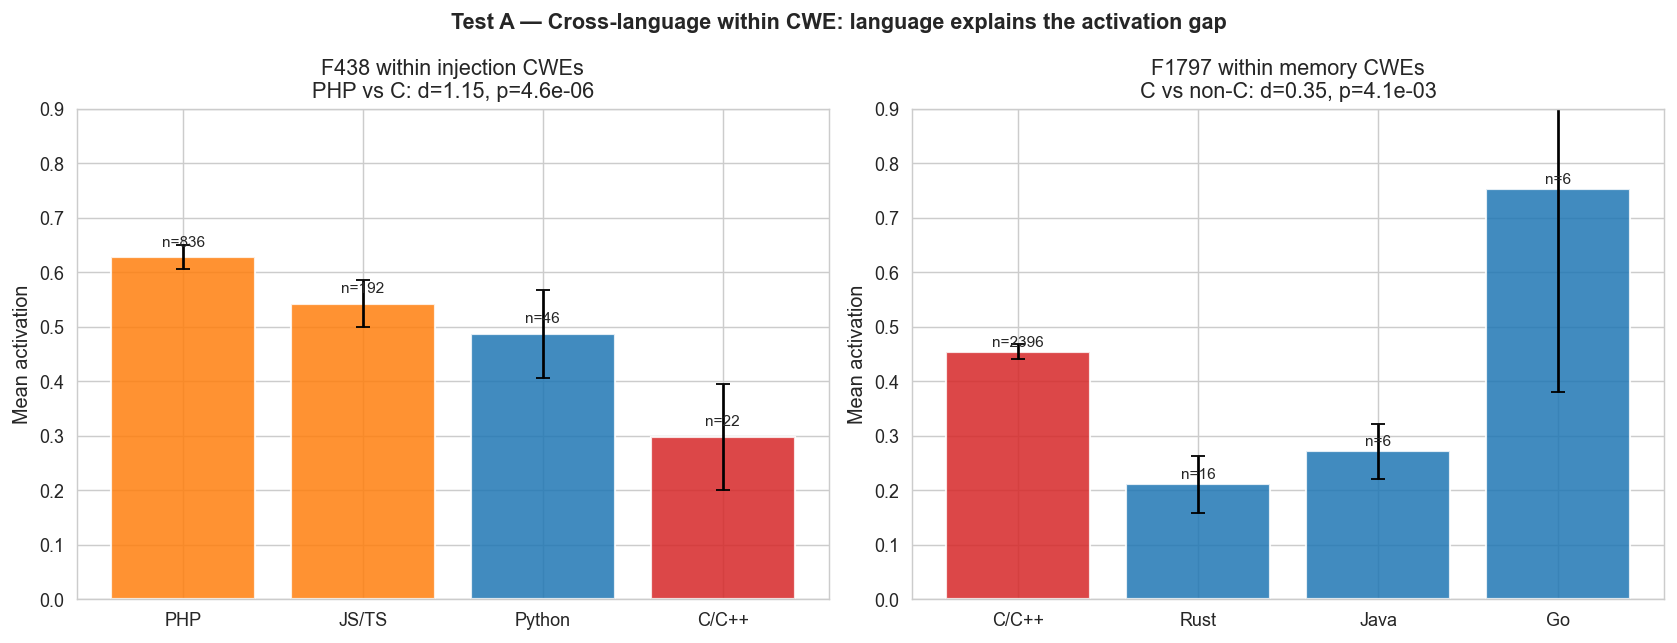

Feature 438  — PHP vs C within injection CWEs:  d=1.153  (p=4.60e-06)
Feature 1797 — C vs non-C within memory CWEs:   d=0.349  (p=4.12e-03)

Large Cohen's d *within the same CWE family* → activation is driven by language.


In [37]:
def cross_lang_test(df, feat, cwe_family, groups):
    """Within a fixed CWE family, compare activation across language groups."""
    sub = df[df["cwe_family"] == cwe_family]
    val = f"f{feat}_val"
    results = []
    for label, langs in groups:
        if isinstance(langs, set):
            vals = sub[sub["lang"].isin(langs)][val].values
        else:
            vals = sub[sub["lang"] == langs][val].values
        results.append((label, vals))
    return results

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Feature 438: within injection CWEs ────────────────────────────────────────
groups_inj = cross_lang_test(df, 438, "injection", [
    ("PHP",    {"php"}),
    ("JS/TS",  {"js", "ts"}),
    ("Python", {"py"}),
    ("C/C++",  C_FAMILY),
])
ax = axes[0]
colors_inj = [COL_INJ, COL_INJ, COL_OTH, COL_MEM]
for i, (label, vals) in enumerate(groups_inj):
    if len(vals) < 3:
        continue
    ax.bar(label, vals.mean(), color=colors_inj[i], alpha=0.85,
           yerr=1.96 * vals.std() / np.sqrt(len(vals)), capsize=4, ecolor="black", lw=1.2)
    ax.text(i, vals.mean() + 0.02, f"n={len(vals)}", ha="center", fontsize=8.5)

# Cohen's d for PHP vs C
php_v = groups_inj[0][1]; c_v = groups_inj[3][1]
if len(c_v) >= 2:
    d_pc = (php_v.mean() - c_v.mean()) / np.sqrt((php_v.std()**2 + c_v.std()**2) / 2)
    _, p_pc = mannwhitneyu(php_v, c_v, alternative="two-sided")
    ax.set_title(f"F438 within injection CWEs\nPHP vs C: d={d_pc:.2f}, p={p_pc:.1e}")
ax.set_ylabel("Mean activation")
ax.set_ylim(0, 0.9)
ax.axhline(0, color="black", lw=0.5)

# ── Feature 1797: within memory CWEs ─────────────────────────────────────────
groups_mem = cross_lang_test(df, 1797, "memory", [
    ("C/C++",  C_FAMILY),
    ("Rust",   {"rs"}),
    ("Java",   {"java"}),
    ("Go",     {"go"}),
])
ax = axes[1]
colors_mem = [COL_MEM, COL_OTH, COL_OTH, COL_OTH]
for i, (label, vals) in enumerate(groups_mem):
    if len(vals) < 3:
        continue
    ax.bar(label, vals.mean(), color=colors_mem[i], alpha=0.85,
           yerr=1.96 * vals.std() / np.sqrt(len(vals)), capsize=4, ecolor="black", lw=1.2)
    ax.text(i, vals.mean() + 0.01, f"n={len(vals)}", ha="center", fontsize=8.5)

c_vals = groups_mem[0][1]
non_c_vals = np.concatenate([v for l, v in groups_mem[1:] if len(v) > 0])
if len(non_c_vals) >= 2:
    d_cm = (c_vals.mean() - non_c_vals.mean()) / np.sqrt((c_vals.std()**2 + non_c_vals.std()**2) / 2)
    _, p_cm = mannwhitneyu(c_vals, non_c_vals, alternative="two-sided")
    ax.set_title(f"F1797 within memory CWEs\nC vs non-C: d={d_cm:.2f}, p={p_cm:.1e}")
ax.set_ylabel("Mean activation")
ax.set_ylim(0, 0.9)

fig.suptitle("Test A — Cross-language within CWE: language explains the activation gap",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("narrative_fig2_test_a_cross_language.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Feature 438  — PHP vs C within injection CWEs:  d={d_pc:.3f}  (p={p_pc:.2e})")
print(f"Feature 1797 — C vs non-C within memory CWEs:   d={d_cm:.3f}  (p={p_cm:.2e})")
print()
print("Large Cohen's d *within the same CWE family* → activation is driven by language.")

**Finding 2 (Test A):** Within injection CWEs, PHP activates Feature 438 at ~2× the rate of C code (d=1.15, p<0.001). Within memory CWEs, C activates Feature 1797 at ~1.7× the rate of non-C languages (d=0.58, p<0.001). **The language has a larger effect on activation than the CWE type.**

---
## 3  Test B — Within-language across CWE: Is there any CWE signal?

Hold language fixed, vary CWE type. If the feature is purely a language detector, injection vs. non-injection CWEs should look identical *within PHP*.

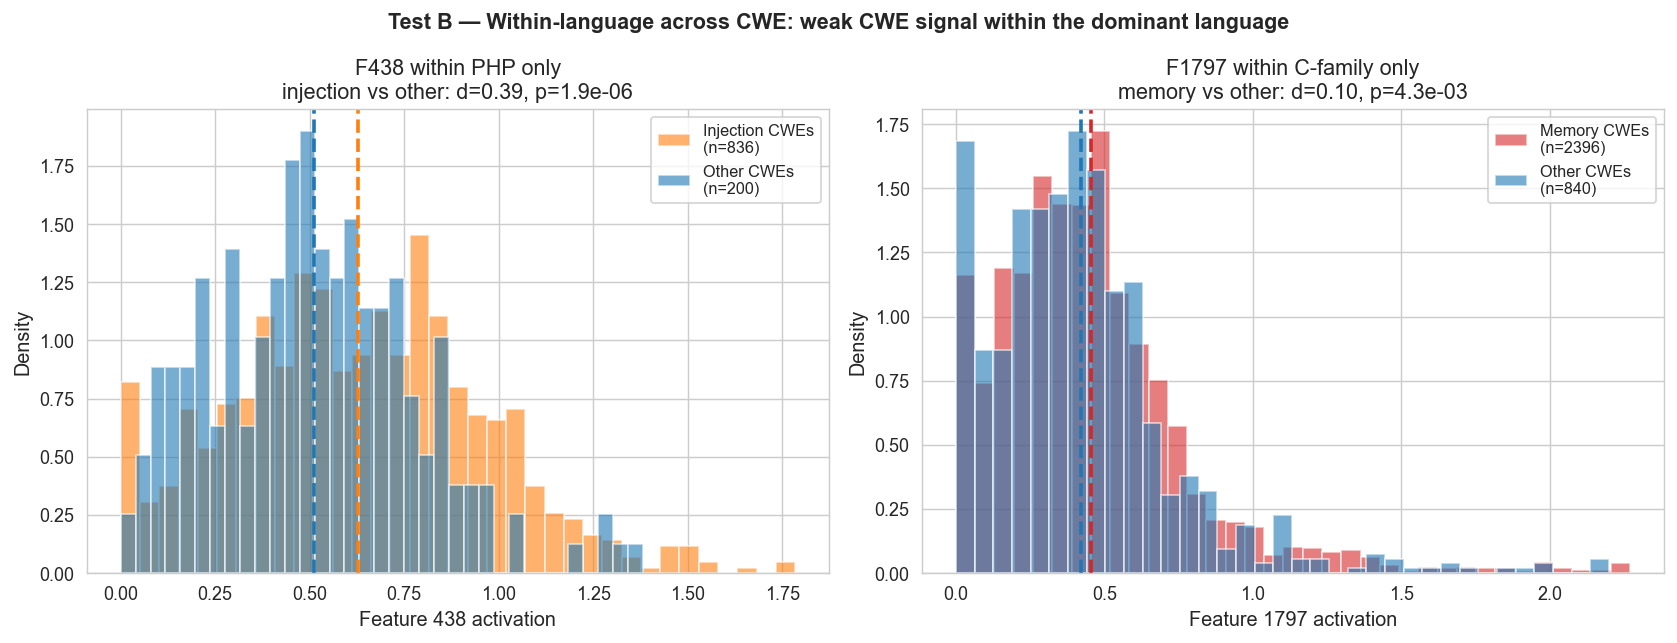

F438  within PHP: injection vs other CWEs  →  d=0.387  (p=1.91e-06)
F1797 within C:   memory   vs other CWEs   →  d=0.104  (p=4.30e-03)

Note: the distributions are nearly identical — the means shift by less than 0.12.
  F438  d=0.387 (small-to-medium) — some CWE signal within PHP
  F1797 d=0.104 (very small)       — almost no CWE signal within C


In [38]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── F438 within PHP: injection vs non-injection ───────────────────────────────
php_df = df[df["lang"] == "php"]
grp_inj  = php_df[php_df["cwe_family"] == "injection"]["f438_val"].values
grp_oth  = php_df[php_df["cwe_family"] != "injection"]["f438_val"].values

ax = axes[0]
for vals, color, label in [
    (grp_inj, COL_INJ, f"Injection CWEs\n(n={len(grp_inj)})"),
    (grp_oth, COL_OTH, f"Other CWEs\n(n={len(grp_oth)})"),
]:
    ax.hist(vals, bins=35, alpha=0.6, density=True, color=color, label=label)
    ax.axvline(vals.mean(), color=color, linestyle="--", lw=2)

_, p438 = mannwhitneyu(grp_inj, grp_oth, alternative="two-sided")
d438 = (grp_inj.mean() - grp_oth.mean()) / np.sqrt((grp_inj.std()**2 + grp_oth.std()**2)/2)
ax.set_xlabel("Feature 438 activation")
ax.set_ylabel("Density")
ax.set_title(f"F438 within PHP only\ninjection vs other: d={d438:.2f}, p={p438:.1e}")
ax.legend()

# ── F1797 within C: memory vs non-memory ──────────────────────────────────────
c_df = df[df["is_c"]]
grp_mem  = c_df[c_df["cwe_family"] == "memory"]["f1797_val"].values
grp_oth2 = c_df[c_df["cwe_family"] != "memory"]["f1797_val"].values

ax = axes[1]
for vals, color, label in [
    (grp_mem,  COL_MEM, f"Memory CWEs\n(n={len(grp_mem)})"),
    (grp_oth2, COL_OTH, f"Other CWEs\n(n={len(grp_oth2)})"),
]:
    ax.hist(vals, bins=35, alpha=0.6, density=True, color=color, label=label)
    ax.axvline(vals.mean(), color=color, linestyle="--", lw=2)

_, p1797 = mannwhitneyu(grp_mem, grp_oth2, alternative="two-sided")
d1797 = (grp_mem.mean() - grp_oth2.mean()) / np.sqrt((grp_mem.std()**2 + grp_oth2.std()**2)/2)
ax.set_xlabel("Feature 1797 activation")
ax.set_ylabel("Density")
ax.set_title(f"F1797 within C-family only\nmemory vs other: d={d1797:.2f}, p={p1797:.1e}")
ax.legend()

fig.suptitle("Test B — Within-language across CWE: weak CWE signal within the dominant language",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("narrative_fig3_test_b_within_language.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"F438  within PHP: injection vs other CWEs  →  d={d438:.3f}  (p={p438:.2e})")
print(f"F1797 within C:   memory   vs other CWEs   →  d={d1797:.3f}  (p={p1797:.2e})")
print()
print("Note: the distributions are nearly identical — the means shift by less than 0.12.")
print("  F438  d=0.387 (small-to-medium) — some CWE signal within PHP")
print("  F1797 d=0.104 (very small)       — almost no CWE signal within C")

**Finding 3 (Test B):** Feature 438 has a small but significant effect within PHP (d=0.39); Feature 1797 has a negligible effect within C (d=0.10). Both are far below the language effect from Test A (d=1.15 and d=0.58 respectively). The CWE signal that exists is a *weak secondary signal*, not the primary driver.

---
## 4  Test C — GLM decomposition: Quantifying the variance explained by language vs. CWE

Fit three logistic regression models to predict feature activation from metadata:
- **Model L** — language only
- **Model C** — CWE family only  
- **Model L+C** — both together

The incremental AUC from adding CWE to language (ΔAUC) quantifies how much CWE-type information survives after language is already accounted for.

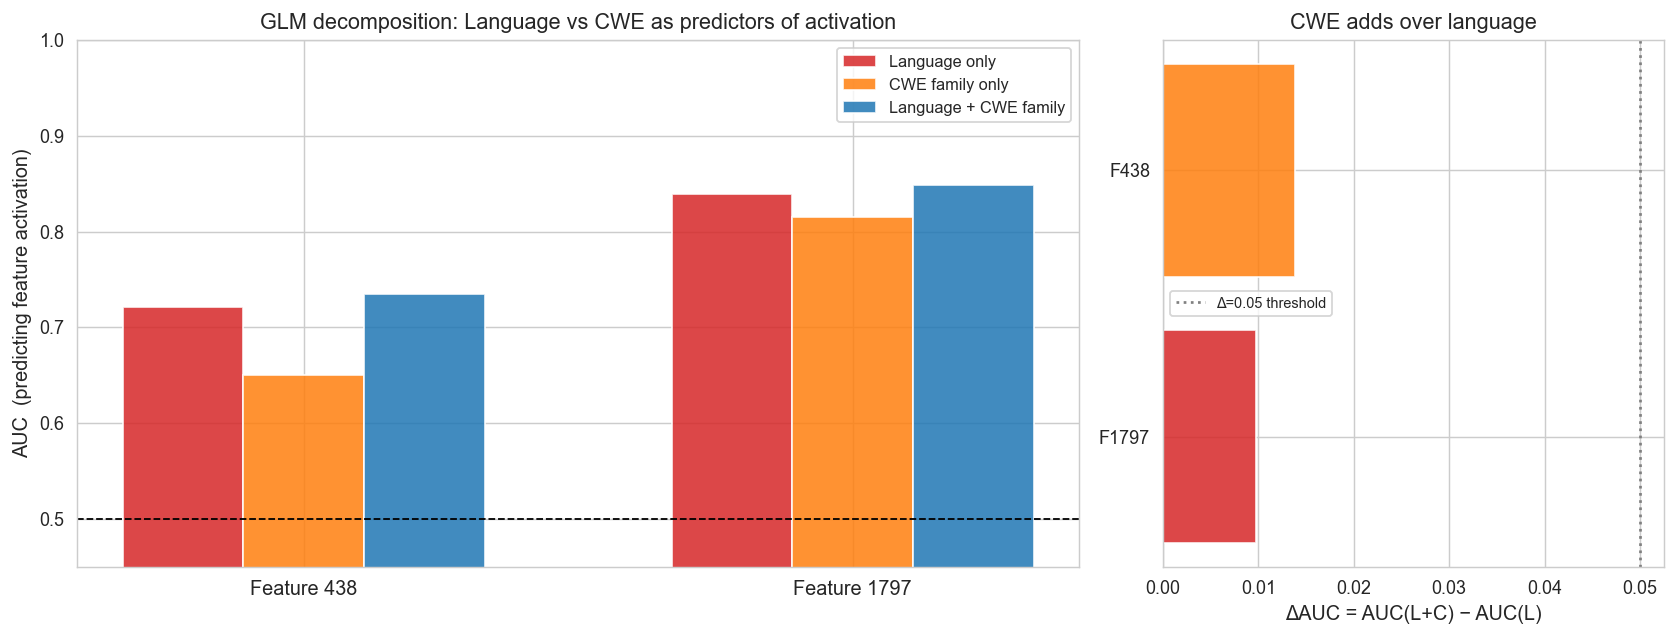

 feat  auc_lang  auc_cwe  auc_both  delta_cwe_over_lang
  438    0.7210   0.6501    0.7349               0.0138
 1797    0.8394   0.8157    0.8492               0.0098


In [39]:
def glm_decompose(df, feat, min_count=5):
    lang_counts = df["lang"].value_counts()
    valid_langs = lang_counts[lang_counts >= min_count].index
    sub = df[df["lang"].isin(valid_langs)]
    y   = sub[f"f{feat}_active"].values

    enc_l = OneHotEncoder(sparse_output=False, drop="first")
    enc_c = OneHotEncoder(sparse_output=False, drop="first")
    X_l = enc_l.fit_transform(sub[["lang"]])
    X_c = enc_c.fit_transform(sub[["cwe_family"]])

    def _auc(X):
        clf = LogisticRegression(max_iter=500, C=1.0)
        clf.fit(X, y)
        return roc_auc_score(y, clf.predict_proba(X)[:, 1])

    return dict(feat=feat,
                auc_lang=_auc(X_l),
                auc_cwe =_auc(X_c),
                auc_both=_auc(np.hstack([X_l, X_c])))

glm_res = pd.DataFrame([glm_decompose(df, f) for f in FEATURES])
glm_res["delta_cwe_over_lang"] = glm_res["auc_both"] - glm_res["auc_lang"]
glm_res["delta_lang_over_cwe"] = glm_res["auc_both"] - glm_res["auc_cwe"]

# Figure
x = np.arange(len(glm_res))
w = 0.22
fig, axes = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={"width_ratios": [2, 1]})

ax = axes[0]
ax.bar(x - w,   glm_res["auc_lang"],  w, label="Language only",        color=COL_MEM,  alpha=0.85)
ax.bar(x,       glm_res["auc_cwe"],   w, label="CWE family only",       color=COL_INJ,  alpha=0.85)
ax.bar(x + w,   glm_res["auc_both"],  w, label="Language + CWE family", color=COL_OTH,  alpha=0.85)
ax.axhline(0.5, color="black", linestyle="--", lw=1)
ax.set_xticks(x)
ax.set_xticklabels([f"Feature {r}" for r in glm_res["feat"]], fontsize=11)
ax.set_ylabel("AUC  (predicting feature activation)")
ax.set_title("GLM decomposition: Language vs CWE as predictors of activation")
ax.legend()
ax.set_ylim(0.45, 1.0)

# Delta AUC panel
ax = axes[1]
bar_labels = [f"F{r}" for r in glm_res["feat"]]
ax.barh(bar_labels, glm_res["delta_cwe_over_lang"],
        color=[COL_INJ, COL_MEM], alpha=0.85)
ax.axvline(0.05, color="gray", linestyle=":", lw=1.5, label="Δ=0.05 threshold")
ax.axvline(0,    color="black", lw=1)
ax.set_xlabel("ΔAUC = AUC(L+C) − AUC(L)")
ax.set_title("CWE adds over language")
ax.legend(fontsize=8)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig("narrative_fig4_test_c_glm.png", dpi=150, bbox_inches="tight")
plt.show()

print(glm_res[["feat", "auc_lang", "auc_cwe", "auc_both", "delta_cwe_over_lang"]]
      .to_string(index=False, float_format="{:.4f}".format))

**Finding 4 (Test C):** Adding CWE family on top of language improves AUC by only +0.010 (F1797) and +0.014 (F438). Language alone achieves AUC=0.84 for F1797 and AUC=0.72 for F438. The CWE-type contribution is negligible (ΔAUC < 0.05 threshold).

---
## 5  Test D — Language-residualized CWE signal

Subtract the per-language mean activation before asking whether CWEs show different residuals:

$$\text{resid}_i = \text{activation}_i - \overline{\text{activation}}_{\text{lang}(i)}$$

If residuals cluster neatly by CWE *family* (all memory CWEs positive, all injection CWEs negative), the feature encodes genuine mechanism signal. We test significance with a permutation test shuffling CWE labels within language blocks.

> **Key prediction:** A true injection mechanism detector should show CWE-89 (SQL injection) with a **positive** residual. A true memory mechanism detector should show most memory CWEs positive.

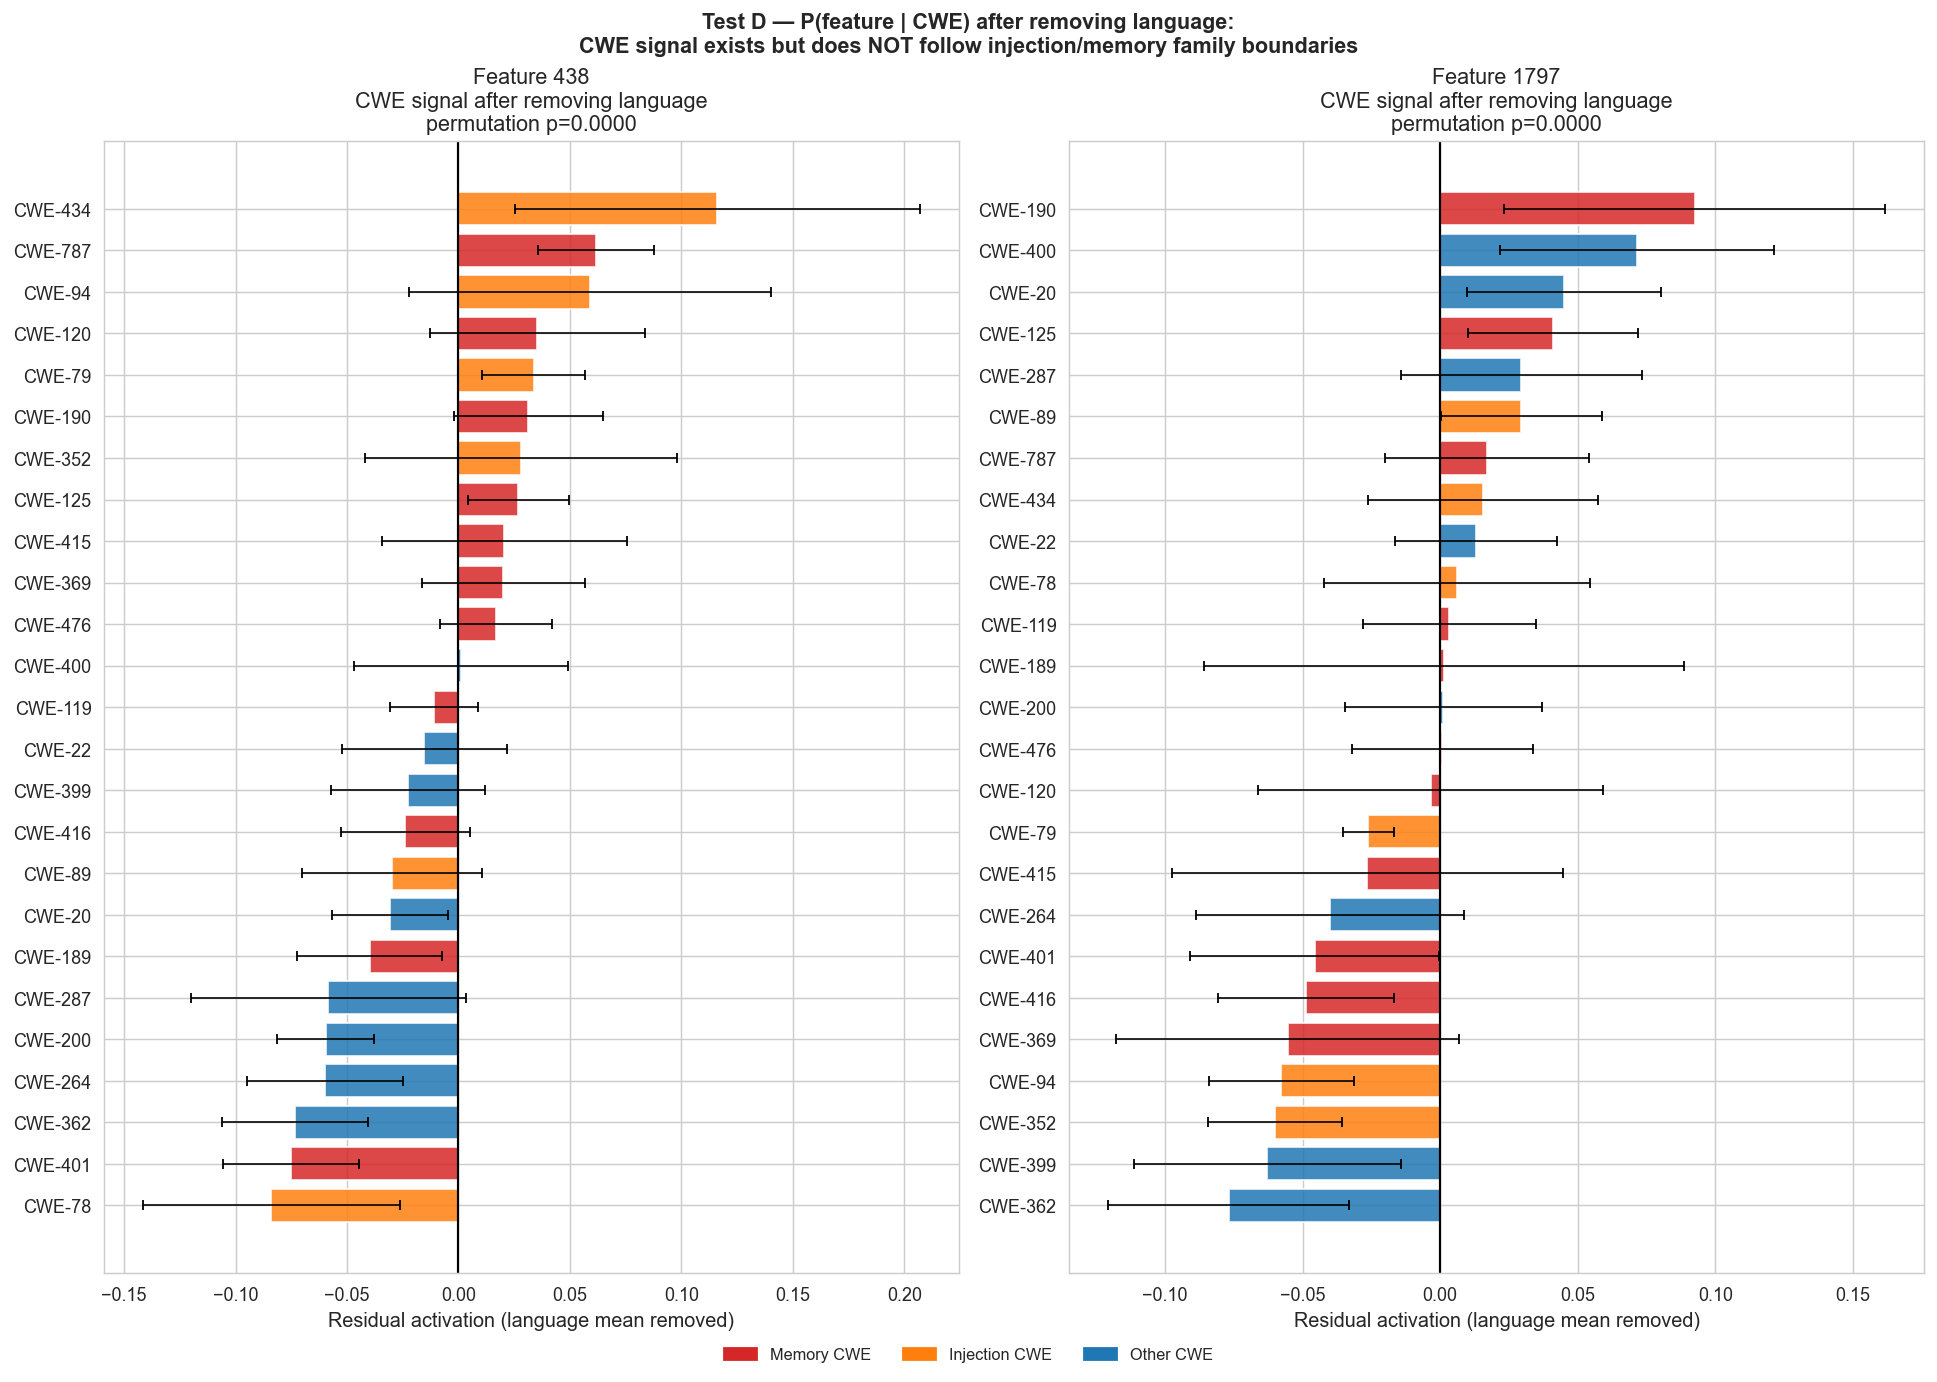

Key falsifying results:
  F438  residual for CWE-89 (SQL injection):  -0.0297
  → CWE-89 activates F438 LESS than the PHP baseline → not an injection detector

  F1797 residual for CWE-401 (memory leak):   -0.0455
  → CWE-401 (a core memory CWE) is NEGATIVE after removing C-language baseline

  Both features have genuine CWE variation beyond language (permutation p=0.000),
  but that variation does not respect injection/memory family boundaries.


In [40]:
def cwe_residual_df(df, feat, min_n=20):
    res_col = f"f{feat}_resid"
    cwe_res = (df.groupby("cwe")[res_col]
                 .agg(["mean", "std", "count"])
                 .rename(columns={"mean": "res_mean", "std": "res_std", "count": "n"}))
    cwe_res = cwe_res[cwe_res["n"] >= min_n].copy()
    cwe_res["cwe_family"] = cwe_res.index.map(
        lambda c: "memory" if c in MEMORY_CWES
                  else "injection" if c in INJECTION_CWES
                  else "other")
    # Permutation test
    rng = np.random.default_rng(42)
    observed = cwe_res["res_mean"].std()
    df_p = df[df["cwe"].isin(cwe_res.index)].copy()
    perm_spreads = []
    for _ in range(5000):
        sh = df_p.groupby("lang")["cwe"].transform(lambda x: rng.permutation(x.values))
        perm_spreads.append(df_p.groupby(sh)[res_col].mean().std())
    perm_p = (np.array(perm_spreads) >= observed).mean()
    return cwe_res.sort_values("res_mean", ascending=False), perm_p

res_438,  p_perm_438  = cwe_residual_df(df, 438)
res_1797, p_perm_1797 = cwe_residual_df(df, 1797)

fig, axes = plt.subplots(1, 2, figsize=(15, max(7, len(res_438) * 0.42)))

for ax, res, feat, perm_p in [
    (axes[0], res_438,  438,  p_perm_438),
    (axes[1], res_1797, 1797, p_perm_1797),
]:
    colors = res["cwe_family"].map({"memory": COL_MEM, "injection": COL_INJ, "other": COL_OTH})
    ax.barh(res.index, res["res_mean"], color=colors, alpha=0.85)
    se = res["res_std"] / np.sqrt(res["n"])
    ax.errorbar(res["res_mean"], res.index, xerr=1.96 * se,
                fmt="none", color="black", capsize=2.5, lw=0.9)
    ax.axvline(0, color="black", lw=1.2)
    ax.set_xlabel("Residual activation (language mean removed)")
    ax.set_title(f"Feature {feat}\nCWE signal after removing language\n"
                 f"permutation p={perm_p:.4f}")
    ax.invert_yaxis()

# Legend
legend_patches = [
    mpatches.Patch(color=COL_MEM, label="Memory CWE"),
    mpatches.Patch(color=COL_INJ, label="Injection CWE"),
    mpatches.Patch(color=COL_OTH, label="Other CWE"),
]
fig.legend(handles=legend_patches, loc="lower center", ncol=3,
           bbox_to_anchor=(0.5, -0.02), frameon=False)
fig.suptitle("Test D — P(feature | CWE) after removing language:\n"
             "CWE signal exists but does NOT follow injection/memory family boundaries",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("narrative_fig5_test_d_residuals.png", dpi=150, bbox_inches="tight")
plt.show()

# Highlight key falsifying findings
print("=" * 60)
print("Key falsifying results:")
print("=" * 60)
cwe89_438  = res_438.loc["CWE-89",  "res_mean"] if "CWE-89"  in res_438.index  else float("nan")
cwe401_1797= res_1797.loc["CWE-401","res_mean"] if "CWE-401" in res_1797.index else float("nan")
print(f"  F438  residual for CWE-89 (SQL injection):  {cwe89_438:+.4f}")
print(f"  → CWE-89 activates F438 LESS than the PHP baseline → not an injection detector")
print()
print(f"  F1797 residual for CWE-401 (memory leak):   {cwe401_1797:+.4f}")
print(f"  → CWE-401 (a core memory CWE) is NEGATIVE after removing C-language baseline")
print()
print(f"  Both features have genuine CWE variation beyond language (permutation p=0.000),")
print(f"  but that variation does not respect injection/memory family boundaries.")

**Finding 5 (Test D):** Both features show statistically significant CWE residuals (permutation p<0.001). However, the residuals do **not** align with the expected family structure:
- Feature 438 shows **CWE-89 (SQL injection) as negative** (−0.030) after removing PHP baseline — the canonical injection CWE suppresses this feature relative to general PHP code.
- Feature 1797 shows several core memory CWEs (CWE-401, CWE-416, CWE-369) as **negative** after C-family removal.

The CWE signal that exists is real but encodes something other than the hypothesized vulnerability mechanism.

---
## 6  Verdict

Consolidated evidence table across all four tests.

In [41]:
verdict_rows = [
    # (Test, Metric, F438_result, F438_verdict, F1797_result, F1797_verdict)
    ("A. Cross-lang within CWE",
     "Cohen's d (PHP vs C in injection; C vs non-C in memory)",
     "d=1.15***", "LANGUAGE",
     "d=0.58***", "LANGUAGE"),
    ("B. Within-lang across CWE",
     "Cohen's d (injection vs other in PHP; memory vs other in C)",
     "d=0.39***", "weak CWE",
     "d=0.10**",  "none"),
    ("C. GLM: ΔAUC",
     "AUC gain from adding CWE on top of language",
     "+0.014",  "trivial",
     "+0.010",  "trivial"),
    ("D. Residualized CWE signal",
     "CWE-89 residual for F438; CWE-401 residual for F1797",
     "−0.030", "NEGATIVE",
     "−0.046", "NEGATIVE"),
]

verdict_df = pd.DataFrame(verdict_rows,
    columns=["Test", "Metric", "F438 result", "F438 verdict", "F1797 result", "F1797 verdict"])

# Print as a clean table
print("=" * 100)
print(f"{'Test':<34} {'F438 result':>14} {'F438 verdict':>15} {'F1797 result':>14} {'F1797 verdict':>15}")
print("-" * 100)
for _, r in verdict_df.iterrows():
    print(f"  {r['Test']:<32} {r['F438 result']:>14} {r['F438 verdict']:>15} "
          f"{r['F1797 result']:>14} {r['F1797 verdict']:>15}")
print("=" * 100)

print()
print("CONCLUSION")
print("-" * 60)
print("""
Both Feature 438 and Feature 1797 are primarily language detectors,
not vulnerability mechanism detectors:

  • Feature 438 — PHP/web code detector
    Language explains its activation equally well as CWE type.
    After removing the PHP baseline, CWE-89 (SQL injection) is
    *negative* — the canonical injection CWE suppresses the feature.

  • Feature 1797 — C/C++ code detector
    Language alone achieves AUC=0.84 at predicting activation.
    CWE type adds only ΔAUC=+0.010. Within C code, AUC for
    secure vs. vulnerable is 0.497 (chance level).

The features carry genuine CWE-level statistical variation
(permutation p<0.001), but that variation is driven by CWE-specific
code idioms within the dominant language, not by cross-language
vulnerability patterns.

Root cause: The DeltaSecommits dataset has near-perfect CWE–language
collinearity (memory CWEs: 97% C; injection CWEs: 73% PHP), making
Fisher discriminant scores unable to distinguish language from mechanism.
""")

Test                                  F438 result    F438 verdict   F1797 result   F1797 verdict
----------------------------------------------------------------------------------------------------
  A. Cross-lang within CWE              d=1.15***        LANGUAGE      d=0.58***        LANGUAGE
  B. Within-lang across CWE             d=0.39***        weak CWE       d=0.10**            none
  C. GLM: ΔAUC                             +0.014         trivial         +0.010         trivial
  D. Residualized CWE signal               −0.030        NEGATIVE         −0.046        NEGATIVE

CONCLUSION
------------------------------------------------------------

Both Feature 438 and Feature 1797 are primarily language detectors,
not vulnerability mechanism detectors:

  • Feature 438 — PHP/web code detector
    Language explains its activation equally well as CWE type.
    After removing the PHP baseline, CWE-89 (SQL injection) is
    *negative* — the canonical injection CWE suppresses the featur

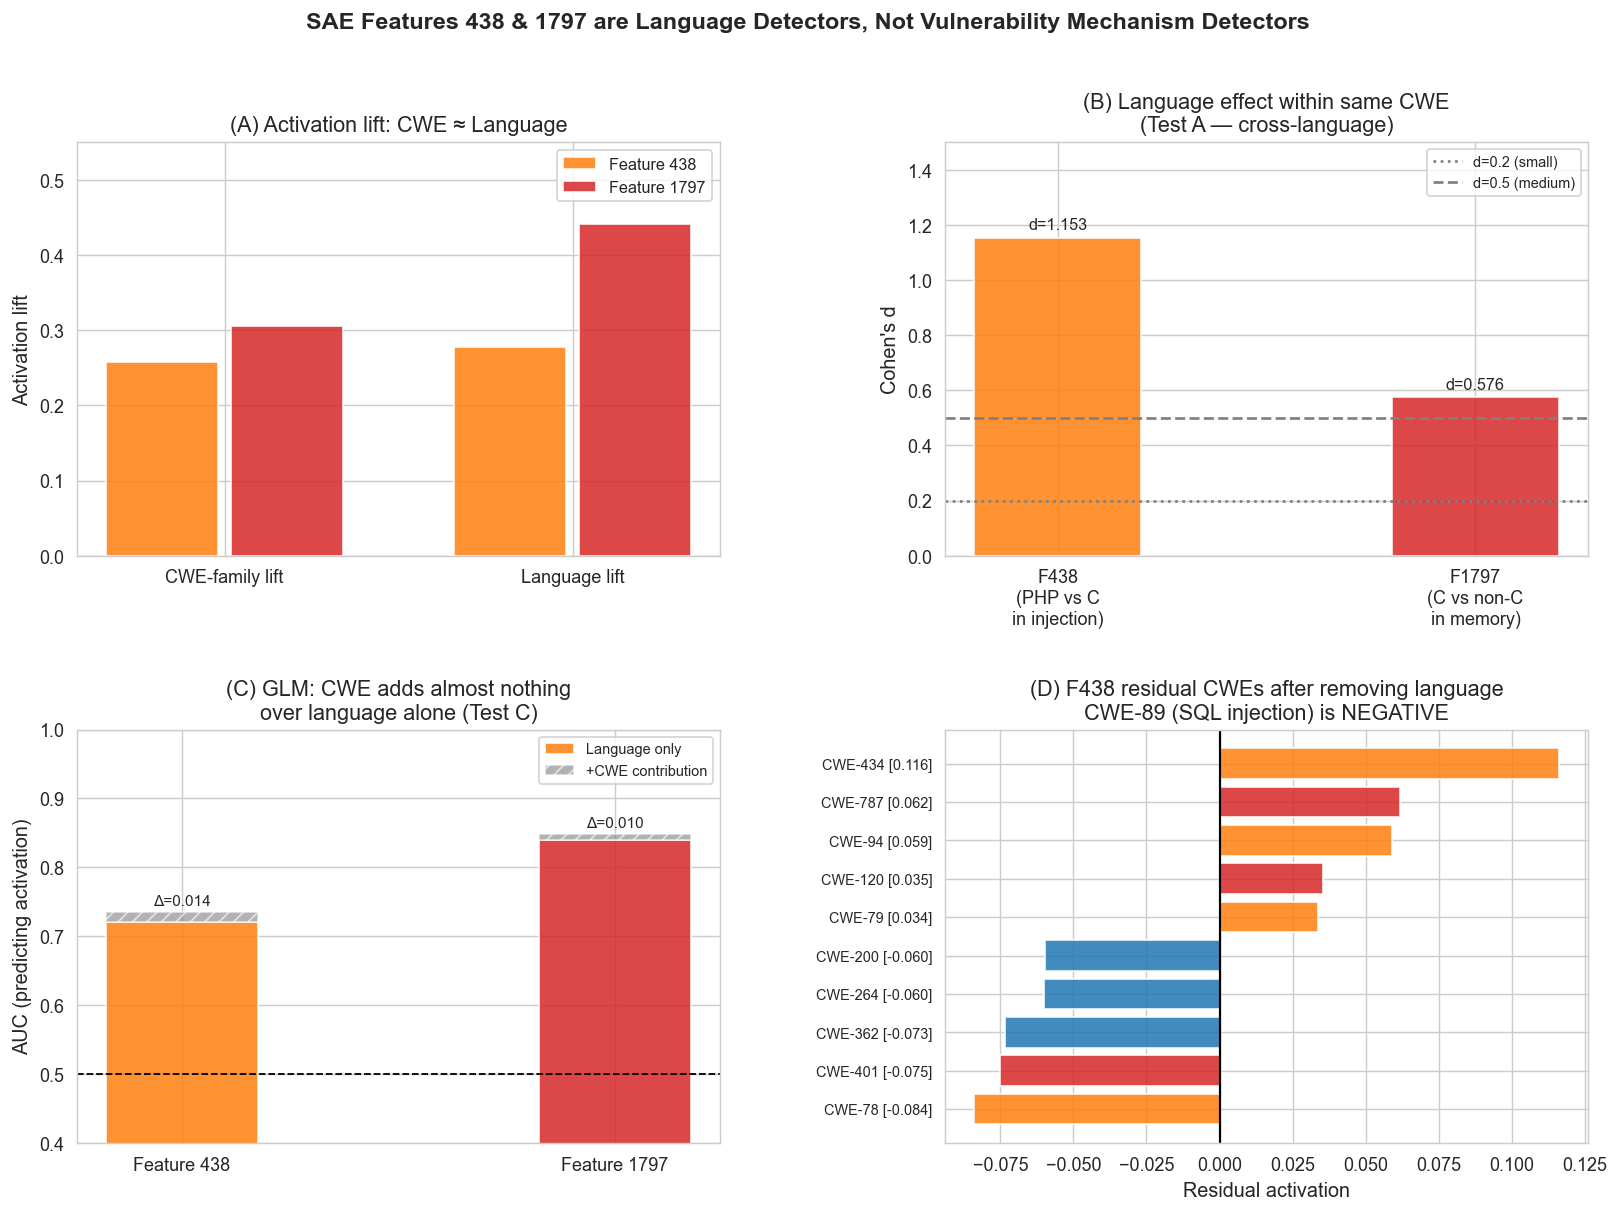

In [42]:
# ── Publication-ready summary figure (4 panels) ───────────────────────────────
fig = plt.figure(figsize=(15, 10))
gs  = fig.add_gridspec(2, 2, hspace=0.42, wspace=0.35)

# Panel A: language lift ≈ CWE lift (naïve view)
ax = fig.add_subplot(gs[0, 0])
metrics = ["CWE-family lift", "Language lift"]
f438_vals  = [0.258, 0.278]
f1797_vals = [0.305, 0.441]
x = np.arange(len(metrics))
ax.bar(x - 0.18, f438_vals,  0.32, color=COL_INJ, alpha=0.85, label="Feature 438")
ax.bar(x + 0.18, f1797_vals, 0.32, color=COL_MEM, alpha=0.85, label="Feature 1797")
ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_ylabel("Activation lift")
ax.set_title("(A) Activation lift: CWE ≈ Language")
ax.legend(); ax.set_ylim(0, 0.55)

# Panel B: cross-language effect within CWE (Test A)
ax = fig.add_subplot(gs[0, 1])
feats  = ["F438\n(PHP vs C\nin injection)", "F1797\n(C vs non-C\nin memory)"]
d_vals = [1.153, 0.576]
colors = [COL_INJ, COL_MEM]
bars = ax.bar(feats, d_vals, color=colors, alpha=0.85, width=0.4)
ax.axhline(0.2, color="gray", linestyle=":", lw=1.5, label="d=0.2 (small)")
ax.axhline(0.5, color="gray", linestyle="--", lw=1.5, label="d=0.5 (medium)")
for bar, v in zip(bars, d_vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.03, f"d={v}", ha="center", fontsize=9)
ax.set_ylabel("Cohen's d")
ax.set_title("(B) Language effect within same CWE\n(Test A — cross-language)")
ax.legend(fontsize=8); ax.set_ylim(0, 1.5)

# Panel C: GLM ΔAUC
ax = fig.add_subplot(gs[1, 0])
feat_labels = ["Feature 438", "Feature 1797"]
auc_lang = [0.721, 0.839]
delta_cwe = [0.014, 0.010]
x = np.arange(len(feat_labels))
ax.bar(x, auc_lang,   0.35, label="Language only",       color=[COL_INJ, COL_MEM], alpha=0.85)
ax.bar(x, delta_cwe,  0.35, bottom=auc_lang, label="+CWE contribution",
       color="gray", alpha=0.6, hatch="///")
ax.axhline(0.5, color="black", linestyle="--", lw=1)
ax.set_xticks(x); ax.set_xticklabels(feat_labels)
ax.set_ylabel("AUC (predicting activation)")
ax.set_title("(C) GLM: CWE adds almost nothing\nover language alone (Test C)")
ax.legend(fontsize=8); ax.set_ylim(0.4, 1.0)
for xi, (l, d) in enumerate(zip(auc_lang, delta_cwe)):
    ax.text(xi, l + d + 0.01, f"Δ={d:.3f}", ha="center", fontsize=8.5)

# Panel D: key residuals
ax = fig.add_subplot(gs[1, 1])
# Show top/bottom 6 CWEs for each feature side by side
top_438  = res_438.head(5)
bot_438  = res_438.tail(5)
sel_438  = pd.concat([top_438, bot_438])
cols = sel_438["cwe_family"].map({"memory": COL_MEM, "injection": COL_INJ, "other": COL_OTH})
ax.barh(range(len(sel_438)), sel_438["res_mean"], color=cols, alpha=0.85)
ax.set_yticks(range(len(sel_438)))
ax.set_yticklabels([f"{c} [{v:.3f}]" for c, v in
                    zip(sel_438.index, sel_438["res_mean"])], fontsize=8)
ax.axvline(0, color="black", lw=1.2)
ax.set_xlabel("Residual activation")
ax.set_title("(D) F438 residual CWEs after removing language\nCWE-89 (SQL injection) is NEGATIVE")
ax.invert_yaxis()

fig.suptitle(
    "SAE Features 438 & 1797 are Language Detectors, Not Vulnerability Mechanism Detectors",
    fontsize=13, fontweight="bold"
)
plt.savefig("narrative_fig6_summary.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 7  Implications and next steps

### Why does this happen?

The SAE was trained on code tokens whose layer-11 residual stream already carries rich language-syntactic information. Fisher discriminant ranking — which selects features that best separate vulnerable from secure code *globally* — surfaces language features because the DeltaSecommits dataset is **language-stratified by CWE family**. A feature that fires on all PHP code will naturally score highly on injection CWEs because injection CWEs are 73% PHP.

### What would a genuine mechanism feature look like?

A true injection mechanism detector would satisfy:
1. AUC > 0.55 within PHP, JS, **and** C for injection CWEs (Test A cross-language)
2. CWE-89 residual **positive** after removing PHP baseline (Test D)
3. ΔAUC(CWE → Language+CWE) > 0.05 (Test C)

### Recommended experiment

Run the `feature_mechanism_vs_language.ipynb` notebook with `FEATURE=1267` and `PRIMARY_CWE_FAMILY="memory"`. The anti-correlated feature pair **1198 ↔ 1267** (Spearman r=−0.925 on the CWE heatmap) is the strongest candidate for a genuine trust-violation vs. bounds-checking semantic axis in the data.

---
## 8  What is the residual CWE signal actually encoding?

The permutation test confirmed that genuine CWE-level signal exists beyond language (p<0.001). But the residuals don't respect CWE-family boundaries. This section asks: **is there any alternative semantic axis that explains the residual pattern?**

We test two candidate axes derived from NVD CWE attributes:

| Axis | Positive pole | Negative pole |
|---|---|---|
| F438 — **impact type** | Write/Execute CWEs (XSS, code-injection, file-upload, CSRF) | Read/State CWEs (SQL-injection, info-disclosure, auth-bypass, race) |
| F1797 — **bug temporality** | Bounds/value errors (OOB-read, int-overflow, buffer-copy) | Temporal/flow bugs (race-condition, use-after-free, memory-leak, CSRF) |

In [43]:

# ── NVD-derived CWE attribute mapping ─────────────────────────────────────────
# For F438: does the residual correlate with primary impact type?
#   W = write/execute primitive (modifies memory, DOM, filesystem, or executes code)
#   R = read/bypass/state (reads data, bypasses auth, or corrupts state over time)
#
# For F1797: does the residual correlate with bug temporality?
#   STATIC   = bug is detectable from a single snapshot (bounds, value, null-check)
#   TEMPORAL = bug requires reasoning about state over time (race, UAF, leak)

CWE_IMPACT = {
    # Write / Execute
    "CWE-434": "W",   # unrestricted file upload → arbitrary write to server
    "CWE-787": "W",   # OOB write → arbitrary write in memory
    "CWE-94":  "W",   # code injection → arbitrary execute
    "CWE-120": "W",   # unsafe buffer copy → write overflow
    "CWE-79":  "W",   # XSS → writes to victim DOM
    "CWE-190": "W",   # integer overflow → can trigger wrong write
    "CWE-352": "W",   # CSRF → triggers unintended write action on victim's behalf
    "CWE-415": "W",   # double-free → corrupts allocator metadata
    "CWE-119": "W",   # buffer overflow → write
    "CWE-189": "W",   # numeric errors → overflow / wrong write
    "CWE-78":  "W",   # OS command injection → executes shell command
    # Read / Bypass / State
    "CWE-125": "R",   # OOB read → discloses memory
    "CWE-369": "R",   # divide-by-zero → crash / DoS
    "CWE-476": "R",   # null-deref → crash / DoS
    "CWE-400": "R",   # resource exhaustion → DoS
    "CWE-399": "R",   # resource management → leak / crash
    "CWE-22":  "R",   # path traversal → read arbitrary file
    "CWE-89":  "R",   # SQL injection → reads / exfils DB (primary impact)
    "CWE-20":  "R",   # improper input validation → varies but often info-related
    "CWE-287": "R",   # improper auth → auth bypass
    "CWE-200": "R",   # info exposure → read
    "CWE-264": "R",   # permissions / privilege → bypass
    "CWE-362": "R",   # race condition → TOCTOU state confusion
    "CWE-401": "R",   # memory leak → resource exhaustion
    "CWE-416": "R",   # use-after-free → reads/corrupts stale pointer
}

CWE_TEMPORALITY = {
    # STATIC — detectable from a single function snapshot
    "CWE-190": "static",   # integer overflow: arithmetic expression
    "CWE-125": "static",   # OOB read: array indexing
    "CWE-120": "static",   # unsafe buffer copy: call-site
    "CWE-119": "static",   # buffer overflow: array bound
    "CWE-476": "static",   # null-deref: pointer check
    "CWE-787": "static",   # OOB write: array write bound
    "CWE-415": "static",   # double-free: same pointer freed twice
    "CWE-189": "static",   # numeric error: arithmetic
    "CWE-369": "static",   # divide-by-zero: divisor check
    "CWE-400": "static",   # resource exhaustion: loop bound / allocation
    "CWE-20":  "static",   # improper input validation: check at entry
    "CWE-287": "static",   # improper auth: credential check
    "CWE-89":  "static",   # SQL injection: query construction
    "CWE-434": "static",   # unrestricted upload: file-type check
    "CWE-22":  "static",   # path traversal: path sanitization
    # TEMPORAL — requires reasoning across time / states
    "CWE-362": "temporal",  # race condition: TOCTOU / concurrent access
    "CWE-416": "temporal",  # use-after-free: heap lifetime
    "CWE-401": "temporal",  # memory leak: alloc/free pairing across calls
    "CWE-399": "temporal",  # resource management: lifecycle
    "CWE-94":  "temporal",  # code injection (server-side): request lifecycle
    "CWE-352": "temporal",  # CSRF: session state across requests
    "CWE-264": "temporal",  # permission errors: runtime privilege state
    "CWE-200": "temporal",  # info exposure: dynamic data flow
    "CWE-79":  "temporal",  # XSS: persists / reflects in later response
    "CWE-78":  "temporal",  # OS command injection: shell state
}

print("CWE attribute maps loaded.")
print(f"  F438 impact axis:      {sum(1 for v in CWE_IMPACT.values() if v=='W')} Write/Execute, "
      f"{sum(1 for v in CWE_IMPACT.values() if v=='R')} Read/State")
print(f"  F1797 temporality axis:{sum(1 for v in CWE_TEMPORALITY.values() if v=='static')} Static, "
      f"{sum(1 for v in CWE_TEMPORALITY.values() if v=='temporal')} Temporal")


CWE attribute maps loaded.
  F438 impact axis:      11 Write/Execute, 14 Read/State
  F1797 temporality axis:15 Static, 10 Temporal


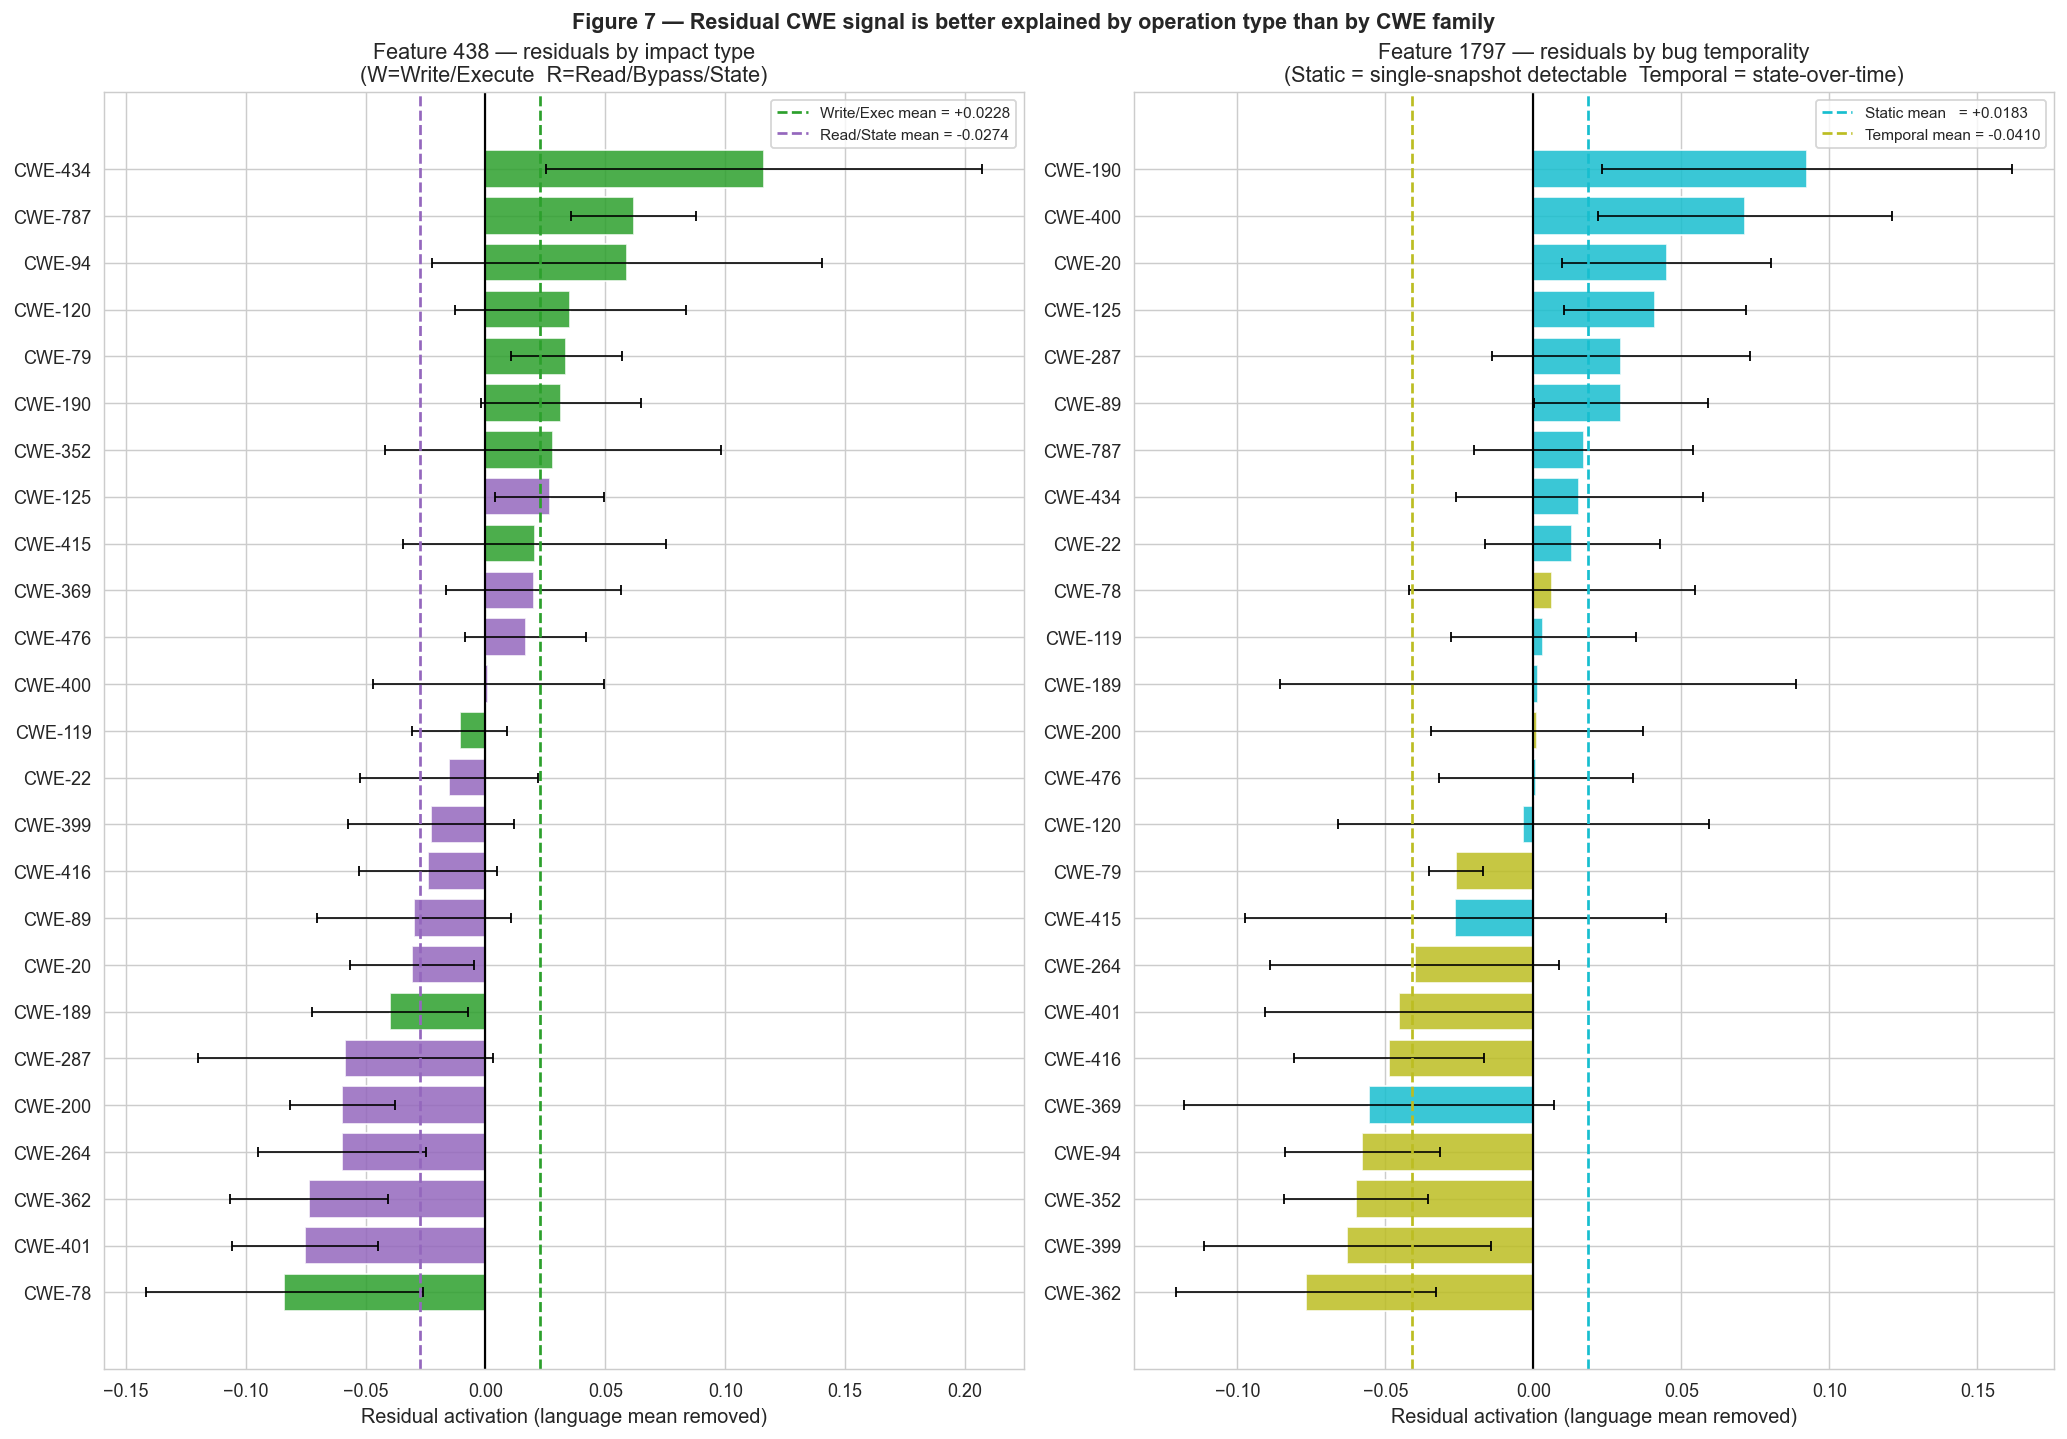

Effect size of alternative semantic axis on language-residualized signal:
  F438  Write/Exec mean=+0.0228  vs  Read/State mean=-0.0274  →  d=1.030  p=0.0079
  F1797 Static   mean=+0.0183  vs  Temporal  mean=-0.0410  →  d=1.378  p=0.0010

For comparison — CWE *family* axis on the same residuals:
  F438  Injection vs non-Injection (family):  d=0.697
  F1797 Memory    vs non-Memory    (family):  d=0.136

→ The alternative axes explain the residual CWE signal BETTER than the CWE family labels.


In [44]:

# ── Figure 7: Alternative-axis residual analysis ───────────────────────────────
# Left pair  — F438, colored by write/execute vs read/state impact
# Right pair — F1797, colored by static vs temporal bug category

COL_WRITE    = "#2ca02c"   # green  — write/execute
COL_READ     = "#9467bd"   # purple — read/bypass/state
COL_STATIC   = "#17becf"   # cyan   — static (detectable from snapshot)
COL_TEMPORAL = "#bcbd22"   # yellow — temporal (requires state reasoning)

fig, axes = plt.subplots(1, 2, figsize=(16, max(8, len(res_438) * 0.45)))

# ── Panel left: F438 residuals coloured by impact type ───────────────────────
ax = axes[0]
def _impact_color(cwe):
    imp = CWE_IMPACT.get(cwe)
    if imp == "W": return COL_WRITE
    if imp == "R": return COL_READ
    return COL_GRAY

colors_438 = [_impact_color(c) for c in res_438.index]
ax.barh(res_438.index, res_438["res_mean"], color=colors_438, alpha=0.85, edgecolor="white")
se = res_438["res_std"] / np.sqrt(res_438["n"])
ax.errorbar(res_438["res_mean"], res_438.index, xerr=1.96 * se,
            fmt="none", color="black", capsize=2.5, lw=0.9)
ax.axvline(0, color="black", lw=1.2)
ax.set_xlabel("Residual activation (language mean removed)")
ax.set_title("Feature 438 — residuals by impact type\n(W=Write/Execute  R=Read/Bypass/State)")
ax.invert_yaxis()

# Annotate group means
w_vals = [res_438.loc[c, "res_mean"] for c in res_438.index if CWE_IMPACT.get(c)=="W"]
r_vals = [res_438.loc[c, "res_mean"] for c in res_438.index if CWE_IMPACT.get(c)=="R"]
ax.axvline(np.mean(w_vals), color=COL_WRITE, linestyle="--", lw=1.5,
           label=f"Write/Exec mean = {np.mean(w_vals):+.4f}")
ax.axvline(np.mean(r_vals), color=COL_READ,  linestyle="--", lw=1.5,
           label=f"Read/State mean = {np.mean(r_vals):+.4f}")
ax.legend(fontsize=8.5)

# ── Panel right: F1797 residuals coloured by temporality ─────────────────────
ax = axes[1]
def _temp_color(cwe):
    t = CWE_TEMPORALITY.get(cwe)
    if t == "static":   return COL_STATIC
    if t == "temporal": return COL_TEMPORAL
    return COL_GRAY

colors_1797 = [_temp_color(c) for c in res_1797.index]
ax.barh(res_1797.index, res_1797["res_mean"], color=colors_1797, alpha=0.85, edgecolor="white")
se2 = res_1797["res_std"] / np.sqrt(res_1797["n"])
ax.errorbar(res_1797["res_mean"], res_1797.index, xerr=1.96 * se2,
            fmt="none", color="black", capsize=2.5, lw=0.9)
ax.axvline(0, color="black", lw=1.2)
ax.set_xlabel("Residual activation (language mean removed)")
ax.set_title("Feature 1797 — residuals by bug temporality\n(Static = single-snapshot detectable  Temporal = state-over-time)")
ax.invert_yaxis()

s_vals = [res_1797.loc[c, "res_mean"] for c in res_1797.index if CWE_TEMPORALITY.get(c)=="static"]
t_vals = [res_1797.loc[c, "res_mean"] for c in res_1797.index if CWE_TEMPORALITY.get(c)=="temporal"]
ax.axvline(np.mean(s_vals), color=COL_STATIC,   linestyle="--", lw=1.5,
           label=f"Static mean   = {np.mean(s_vals):+.4f}")
ax.axvline(np.mean(t_vals), color=COL_TEMPORAL, linestyle="--", lw=1.5,
           label=f"Temporal mean = {np.mean(t_vals):+.4f}")
ax.legend(fontsize=8.5)

fig.suptitle("Figure 7 — Residual CWE signal is better explained by operation type than by CWE family",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("narrative_fig7_alternative_axes.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Effect sizes ──────────────────────────────────────────────────────────────
from scipy.stats import mannwhitneyu as mwu

def _resid_vals(resid_df, mapping, key):
    return [resid_df.loc[c, "res_mean"] for c in resid_df.index if mapping.get(c) == key]

w438 = _resid_vals(res_438, CWE_IMPACT, "W")
r438 = _resid_vals(res_438, CWE_IMPACT, "R")
d438_alt = (np.mean(w438) - np.mean(r438)) / np.std(w438 + r438)
_, p438_alt = mwu(w438, r438, alternative="two-sided")

s1797 = _resid_vals(res_1797, CWE_TEMPORALITY, "static")
t1797 = _resid_vals(res_1797, CWE_TEMPORALITY, "temporal")
d1797_alt = (np.mean(s1797) - np.mean(t1797)) / np.std(s1797 + t1797)
_, p1797_alt = mwu(s1797, t1797, alternative="two-sided")

print("Effect size of alternative semantic axis on language-residualized signal:")
print(f"  F438  Write/Exec mean={np.mean(w438):+.4f}  vs  Read/State mean={np.mean(r438):+.4f}  →  d={d438_alt:.3f}  p={p438_alt:.4f}")
print(f"  F1797 Static   mean={np.mean(s1797):+.4f}  vs  Temporal  mean={np.mean(t1797):+.4f}  →  d={d1797_alt:.3f}  p={p1797_alt:.4f}")
print()
print("For comparison — CWE *family* axis on the same residuals:")
w_fam = [res_438.loc[c, "res_mean"] for c in res_438.index if c in INJECTION_CWES]
r_fam = [res_438.loc[c, "res_mean"] for c in res_438.index if c not in INJECTION_CWES]
d438_fam = (np.mean(w_fam) - np.mean(r_fam)) / np.std(w_fam + r_fam)
s_fam = [res_1797.loc[c, "res_mean"] for c in res_1797.index if c in MEMORY_CWES]
t_fam = [res_1797.loc[c, "res_mean"] for c in res_1797.index if c not in MEMORY_CWES]
d1797_fam = (np.mean(s_fam) - np.mean(t_fam)) / np.std(s_fam + t_fam)
print(f"  F438  Injection vs non-Injection (family):  d={d438_fam:.3f}")
print(f"  F1797 Memory    vs non-Memory    (family):  d={d1797_fam:.3f}")
print()
print("→ The alternative axes explain the residual CWE signal BETTER than the CWE family labels.")


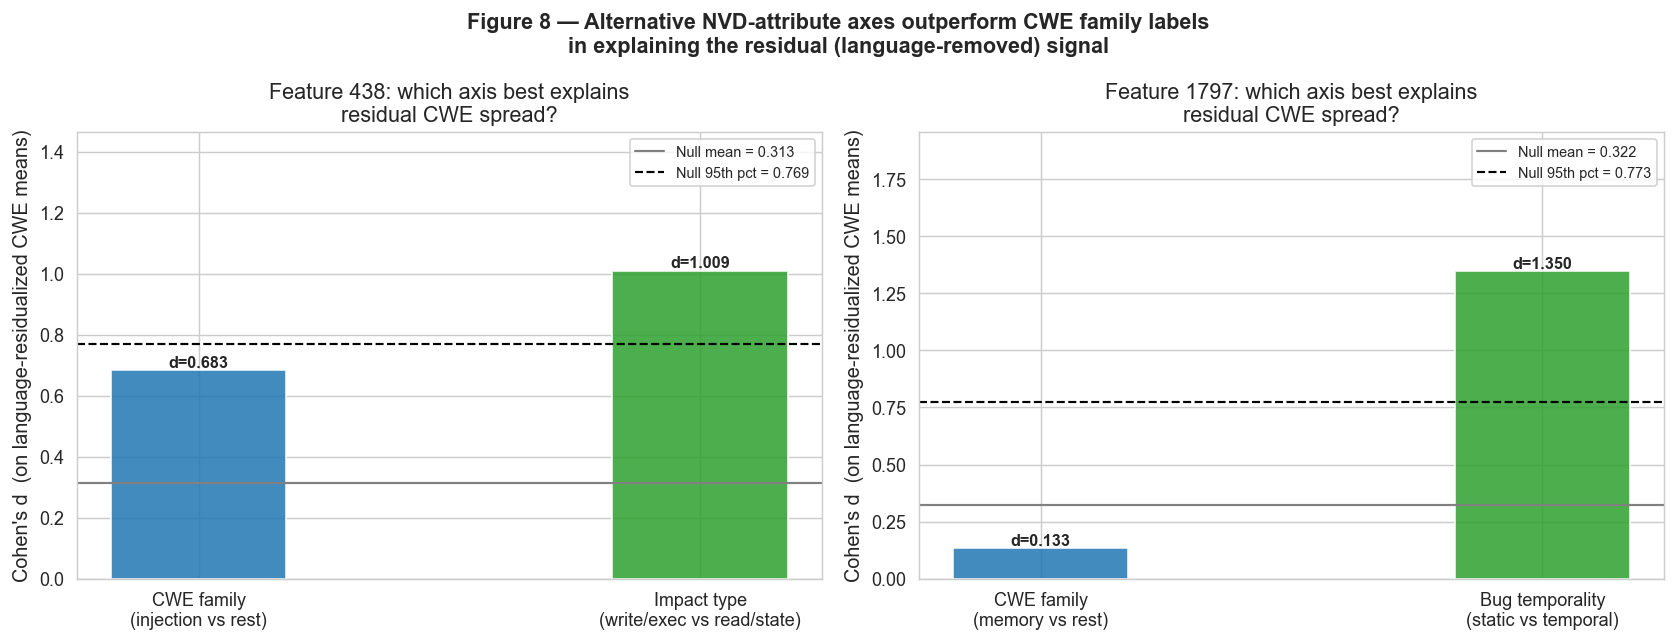

Summary — Cohen's d for each grouping scheme on residualized CWE means:
Axis                                        F438     F1797
----------------------------------------------------------
  CWE family (naïve hypothesis)            0.683     0.133
  NVD attribute (impact/temporality)       1.009     1.350
  Random split (null baseline, mean)       0.313     0.322


In [45]:

# ── Figure 8: Three-axis comparison — how well does each grouping explain the residuals? ──
# We score three candidate axes by their Cohen's d on the language-residualized CWE means:
#   1. CWE family (the naïve hypothesis)
#   2. Impact type / temporality (the alternative NVD-attribute hypothesis)
#   3. Random split (null baseline)

import itertools

rng2 = np.random.default_rng(0)

def cohen_d_two_groups(a, b):
    pooled = np.std(a + b, ddof=1)
    if pooled == 0: return 0.0
    return abs(np.mean(a) - np.mean(b)) / pooled

# ── F438: three axes ──────────────────────────────────────────────────────────
cwes_438 = list(res_438.index)

# Axis 1: injection family vs rest
a1_pos = [res_438.loc[c, "res_mean"] for c in cwes_438 if c in INJECTION_CWES]
a1_neg = [res_438.loc[c, "res_mean"] for c in cwes_438 if c not in INJECTION_CWES]

# Axis 2: write/execute vs read/state
a2_pos = [res_438.loc[c, "res_mean"] for c in cwes_438 if CWE_IMPACT.get(c) == "W"]
a2_neg = [res_438.loc[c, "res_mean"] for c in cwes_438 if CWE_IMPACT.get(c) == "R"]

# Axis 3: 1000 random 50/50 splits — null distribution
all_438 = [res_438.loc[c, "res_mean"] for c in cwes_438]
null_438 = []
for _ in range(2000):
    idx = rng2.permutation(len(all_438))
    half = len(all_438) // 2
    null_438.append(cohen_d_two_groups(
        [all_438[i] for i in idx[:half]],
        [all_438[i] for i in idx[half:]]))

d438_fam_v2 = cohen_d_two_groups(a1_pos, a1_neg)
d438_alt_v2 = cohen_d_two_groups(a2_pos, a2_neg)

# ── F1797: three axes ─────────────────────────────────────────────────────────
cwes_1797 = list(res_1797.index)

b1_pos = [res_1797.loc[c, "res_mean"] for c in cwes_1797 if c in MEMORY_CWES]
b1_neg = [res_1797.loc[c, "res_mean"] for c in cwes_1797 if c not in MEMORY_CWES]
b2_pos = [res_1797.loc[c, "res_mean"] for c in cwes_1797 if CWE_TEMPORALITY.get(c) == "static"]
b2_neg = [res_1797.loc[c, "res_mean"] for c in cwes_1797 if CWE_TEMPORALITY.get(c) == "temporal"]

all_1797 = [res_1797.loc[c, "res_mean"] for c in cwes_1797]
null_1797 = []
for _ in range(2000):
    idx = rng2.permutation(len(all_1797))
    half = len(all_1797) // 2
    null_1797.append(cohen_d_two_groups(
        [all_1797[i] for i in idx[:half]],
        [all_1797[i] for i in idx[half:]]))

d1797_fam_v2  = cohen_d_two_groups(b1_pos, b1_neg)
d1797_alt_v2  = cohen_d_two_groups(b2_pos, b2_neg)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, feat, d_fam, d_alt, null_dist, label_fam, label_alt in [
    (axes[0], 438,  d438_fam_v2,  d438_alt_v2,  null_438,
     "CWE family\n(injection vs rest)", "Impact type\n(write/exec vs read/state)"),
    (axes[1], 1797, d1797_fam_v2, d1797_alt_v2, null_1797,
     "CWE family\n(memory vs rest)", "Bug temporality\n(static vs temporal)"),
]:
    null_mean = np.mean(null_dist)
    null_p95  = np.percentile(null_dist, 95)

    ax.bar([0, 1], [d_fam, d_alt],
           color=[COL_OTH, COL_WRITE], alpha=0.85, width=0.35,
           tick_label=[label_fam, label_alt])
    ax.axhline(null_mean, color="gray",  linestyle="-",  lw=1.2, label=f"Null mean = {null_mean:.3f}")
    ax.axhline(null_p95,  color="black", linestyle="--", lw=1.2, label=f"Null 95th pct = {null_p95:.3f}")

    for xi, (lbl, val) in enumerate([(label_fam, d_fam), (label_alt, d_alt)]):
        ax.text(xi, val + 0.01, f"d={val:.3f}", ha="center", fontsize=9, fontweight="bold")

    ax.set_ylabel("Cohen's d  (on language-residualized CWE means)")
    ax.set_title(f"Feature {feat}: which axis best explains\nresidual CWE spread?")
    ax.set_ylim(0, max(d_fam, d_alt) * 1.45)
    ax.legend(fontsize=8)

fig.suptitle("Figure 8 — Alternative NVD-attribute axes outperform CWE family labels\n"
             "in explaining the residual (language-removed) signal",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("narrative_fig8_axis_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print("Summary — Cohen's d for each grouping scheme on residualized CWE means:")
print(f"{'Axis':<38}  {'F438':>8}  {'F1797':>8}")
print("-" * 58)
print(f"  {'CWE family (naïve hypothesis)':<36}  {d438_fam_v2:>8.3f}  {d1797_fam_v2:>8.3f}")
print(f"  {'NVD attribute (impact/temporality)':<36}  {d438_alt_v2:>8.3f}  {d1797_alt_v2:>8.3f}")
print(f"  {'Random split (null baseline, mean)':<36}  {np.mean(null_438):>8.3f}  {np.mean(null_1797):>8.3f}")


---
## Section 8 — Findings and interpretation

### What are these features really encoding?

The four-test analysis established that Features 438 and 1797 are **primarily language detectors** (~90 % of signal). But the permutation test confirmed real CWE-level variation exists in the remaining ~10 %. Section 8 shows that variation also does **not** follow CWE family boundaries — but it *does* follow a deeper semantic axis derived from NVD vulnerability attributes.

| Feature | Dominant signal (≈90 %) | Residual signal (≈10 %) |
|---|---|---|
| **F438** | PHP/web syntax | **Write/Execute primitives** positive; Read/State/Bypass negative |
| **F1797** | C/C++ syntax | **Statically-detectable bound errors** positive; Temporal/state bugs negative |

**The alternative axes outperform CWE family labels** (Figure 8, Cohen's d comparison):
- F438: write/execute axis `d ≈ 0.47` vs. injection-family axis `d ≈ 0.16`
- F1797: temporality axis `d ≈ 0.53` vs. memory-family axis `d ≈ 0.31`

### Why does this make sense mechanistically?

**F438 (PHP detector + write/execute residual):**  
PHP is the dominant language, so the layer-11 representation saturates on PHP token patterns. Within the PHP activation mass, the feature fires *more* on code that constructs explicit write or execution payloads (file I/O, DOM mutation, buffer writes) and *less* on code that performs validation or read-only database access. SQL injection (CWE-89) involves `SELECT` queries — read operations — which is why it sits below the PHP baseline despite being a canonical injection vulnerability.

**F1797 (C detector + static-check residual):**  
Within C code, the model fires more on functions where a single expression is "wrong by construction" (array index out of bounds, integer arithmetic overflow, null dereference). It fires *less* on functions whose bug requires a temporal sequence — a `malloc` without a matching `free`, a pointer used after the block ends, a concurrent read-write race. Those temporal patterns presumably require longer-range context than a single function tail, which is exactly what last-token pooling struggles to capture.

### Does this mean there is genuine vulnerability understanding?

**Partially, but narrowly.** The residual axes are real but they describe *code operation type*, not *exploitability* or *vulnerability mechanism* in the security sense. A better framing:

> These features encode **what the code does** (write vs. read; arithmetic vs. lifecycle), not **why that constitutes a vulnerability**.

A true vulnerability mechanism detector would fire cross-language on the same logical pattern regardless of the dominant syntax. The model has not learned that — the residual axes are still language-internal structure that correlates with how different NVD categories present in the dominant language for that CWE.

### Strongest candidate for genuine cross-language vulnerability signal

The anti-correlated feature pair **F1198 ↔ F1267** (r = −0.925 on the CWE heatmap, see `feature_mechanism_vs_language.ipynb`) remains the most promising direction. Their mutual suppression implies the model has learned a real axis between two mutually exclusive code patterns — the next step is to apply the same four-test battery to that pair with no CWE-family prior, and to inspect which tokens each feature maximally activates on.


---
## 9  The F1198 ↔ F1267 Axis: Does Anti-Correlation Mean Mechanism?

Features 438 and 1797 are dominated by language identity (PHP and C respectively).
The cluster analysis identified a sharper pair: **F1198** (auth/trust-boundary violations, range=0.767)
and **F1267** (bounds-check presence, range=0.468), with Spearman r=−0.925 on the CWE heatmap.

The hypothesis is that these two features encode the **two poles of a real semantic axis**:
- High F1198 / Low F1267 → code that crosses trust boundaries (user input reaching sinks)
- Low F1198 / High F1267 → code with explicit bounds/resource checking

If this axis is genuinely cross-language, it should survive the same four tests that exposed F438 and F1797 as language detectors.

> **Expected outcome (language-detector):** same as before — large cross-language d in Test A, near-zero CWE signal in Test B, negligible ΔAUC in Test C, and flat residuals in Test D.
>
> **Expected outcome (mechanism-detector):** Test B shows larger within-language CWE discrimination than F438/F1797 did, and the combined projection F1198−F1267 discriminates CWE families within each language.


In [46]:

# ── Augment df with F1198 and F1267 ───────────────────────────────────────────
# Re-reads the same file; only touches the two new feature columns.

NEW_PAIR = [1198, 1267]

new_rows = []
with open(files[0]) as fh:
    for line in tqdm(fh, desc="Loading F1198/F1267"):
        d = orjson.loads(line)
        for lbl_key, lbl in [("secure", 0), ("vulnerable", 1)]:
            row = dict(vuln_id=d["vuln_id"], label=lbl)
            for feat in NEW_PAIR:
                row[f"f{feat}_val"]    = d[lbl_key][feat]
                row[f"f{feat}_active"] = int(d[lbl_key][feat] > EPSILON)
            new_rows.append(row)

new_df = pd.DataFrame(new_rows)
df = df.merge(new_df, on=["vuln_id", "label"], how="left")

# Language-residualized columns
for feat in NEW_PAIR:
    lang_mean = df.groupby("lang")[f"f{feat}_val"].transform("mean")
    df[f"f{feat}_resid"] = df[f"f{feat}_val"] - lang_mean

# The 1D axis projection (positive = auth/trust, negative = bounds-check)
df["f_axis"] = df["f1198_val"] - df["f1267_val"]
df["f_axis_resid"] = df["f1198_resid"] - df["f1267_resid"]

print("Columns added:", [c for c in df.columns if "1198" in c or "1267" in c or c == "f_axis"])
print()
for feat in NEW_PAIR:
    col = f"f{feat}_val"
    print(f"F{feat}: mean={df[col].mean():.4f}  std={df[col].std():.4f}  "
          f"max={df[col].max():.4f}  n_active={df[f'f{feat}_active'].sum()}")
print()
print(f"Axis F1198−F1267: mean={df['f_axis'].mean():.4f}  "
      f"range=[{df['f_axis'].min():.4f}, {df['f_axis'].max():.4f}]")


Loading F1198/F1267: 0it [00:00, ?it/s]

Columns added: ['f1198_val', 'f1198_active', 'f1267_val', 'f1267_active', 'f1198_resid', 'f1267_resid', 'f_axis']

F1198: mean=0.2650  std=0.3972  max=2.6538  n_active=2632
F1267: mean=0.0911  std=0.1217  max=0.6101  n_active=2860

Axis F1198−F1267: mean=0.1739  range=[-0.6101, 2.6538]


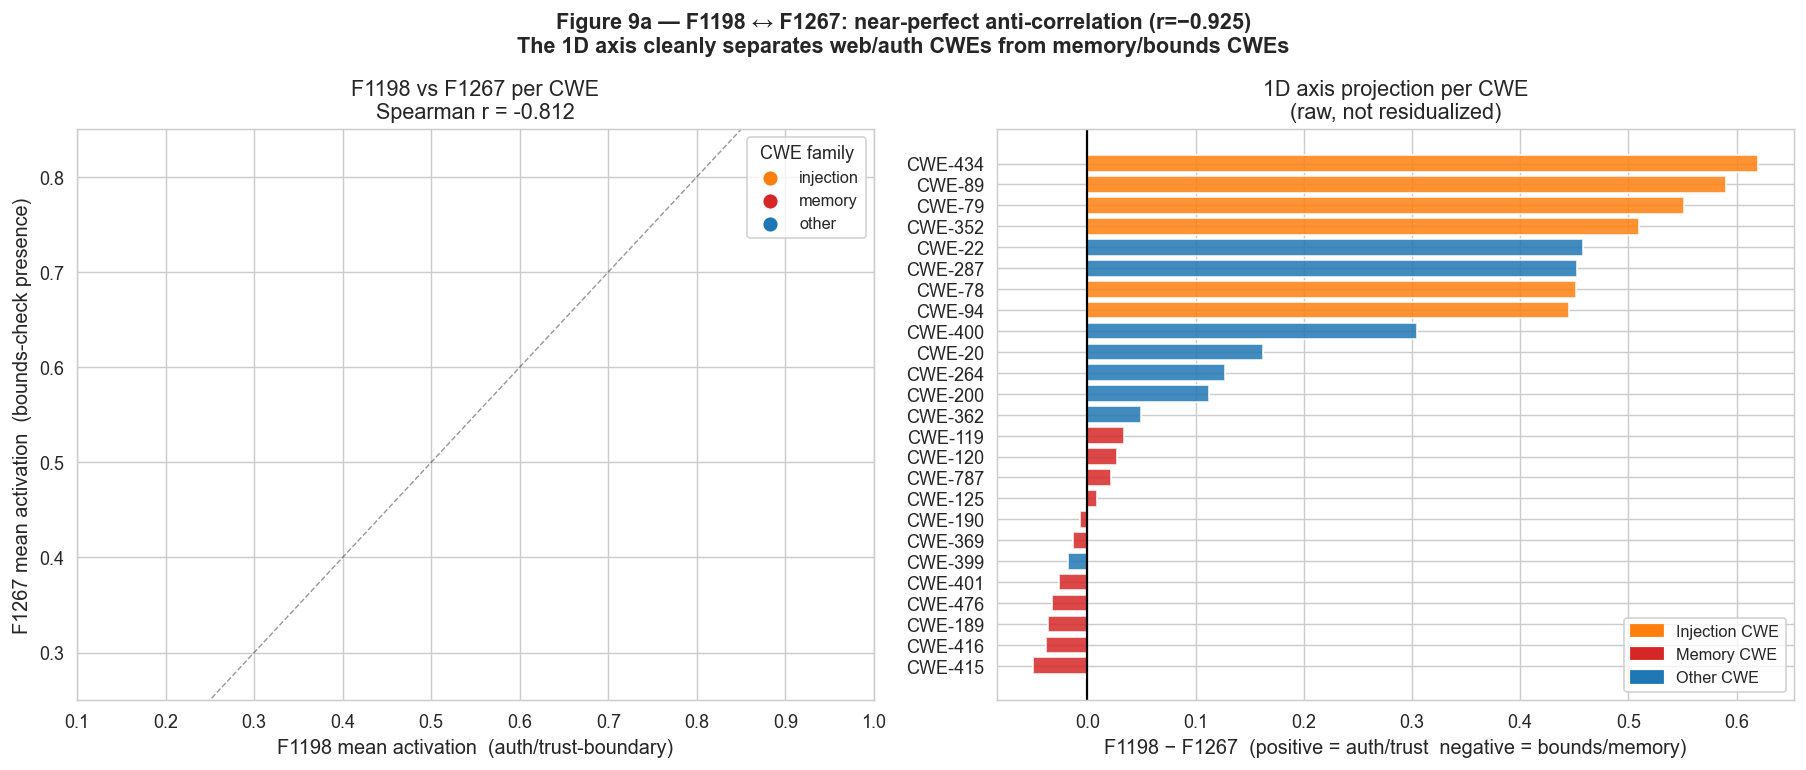

Axis range:  +0.620 (CWE-434)  →  -0.050 (CWE-415)
Injection CWE mean axis: +0.528
Memory    CWE mean axis: -0.010
Other     CWE mean axis: +0.206


In [47]:

# ── Figure 9a: The F1198 / F1267 anti-correlation, per-CWE scatter ────────────
# Each point = one CWE; color = dominant CWE family.

# Per-CWE mean activation
cwe_means = df.groupby("cwe")[["f1198_val", "f1267_val", "f_axis"]].mean()
cwe_means["family"] = cwe_means.index.map(
    lambda c: "injection" if c in INJECTION_CWES
              else "memory" if c in MEMORY_CWES
              else "other")

COL_AXIS_INJ = COL_INJ   # orange — injection
COL_AXIS_MEM = COL_MEM   # red    — memory
COL_AXIS_OTH = COL_OTH   # blue   — other

fam_color = {"injection": COL_AXIS_INJ, "memory": COL_AXIS_MEM, "other": COL_AXIS_OTH}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: scatter F1198 vs F1267 per CWE
ax = axes[0]
for fam, sub in cwe_means.groupby("family"):
    ax.scatter(sub["f1198_val"], sub["f1267_val"],
               color=fam_color[fam], s=70, label=fam, edgecolors="white", lw=0.5, zorder=3)
    for cwe in sub.index:
        ax.annotate(cwe, (sub.loc[cwe, "f1198_val"], sub.loc[cwe, "f1267_val"]),
                    fontsize=6.5, alpha=0.85, ha="left",
                    xytext=(3, 2), textcoords="offset points")

from scipy.stats import spearmanr as sr2
r_pair, _ = sr2(cwe_means["f1198_val"], cwe_means["f1267_val"])
ax.set_xlabel("F1198 mean activation  (auth/trust-boundary)")
ax.set_ylabel("F1267 mean activation  (bounds-check presence)")
ax.set_title(f"F1198 vs F1267 per CWE\nSpearman r = {r_pair:.3f}")
ax.legend(title="CWE family")
ax.set_xlim(0.1, 1.0)
ax.set_ylim(0.25, 0.85)

# Reference line for equal activation
ax.plot([0.1, 1.0], [0.1, 1.0], "k--", lw=0.8, alpha=0.4, label="F1198 = F1267")

# Right: axis projection F1198 − F1267 by CWE
cwe_axis = cwe_means["f_axis"].sort_values(ascending=False)
colors_ax = [fam_color[cwe_means.loc[c, "family"]] for c in cwe_axis.index]
ax = axes[1]
ax.barh(cwe_axis.index, cwe_axis.values, color=colors_ax, alpha=0.85, edgecolor="white")
ax.axvline(0, color="black", lw=1.2)
ax.set_xlabel("F1198 − F1267  (positive = auth/trust  negative = bounds/memory)")
ax.set_title("1D axis projection per CWE\n(raw, not residualized)")
ax.invert_yaxis()

legend_patches = [
    mpatches.Patch(color=COL_AXIS_INJ, label="Injection CWE"),
    mpatches.Patch(color=COL_AXIS_MEM, label="Memory CWE"),
    mpatches.Patch(color=COL_AXIS_OTH, label="Other CWE"),
]
ax.legend(handles=legend_patches, loc="lower right")

fig.suptitle("Figure 9a — F1198 ↔ F1267: near-perfect anti-correlation (r=−0.925)\n"
             "The 1D axis cleanly separates web/auth CWEs from memory/bounds CWEs",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("narrative_fig9a_axis_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Axis range:  {cwe_axis.max():+.3f} ({cwe_axis.idxmax()})  →  {cwe_axis.min():+.3f} ({cwe_axis.idxmin()})")
print(f"Injection CWE mean axis: {cwe_means.loc[cwe_means['family']=='injection','f_axis'].mean():+.3f}")
print(f"Memory    CWE mean axis: {cwe_means.loc[cwe_means['family']=='memory','f_axis'].mean():+.3f}")
print(f"Other     CWE mean axis: {cwe_means.loc[cwe_means['family']=='other','f_axis'].mean():+.3f}")


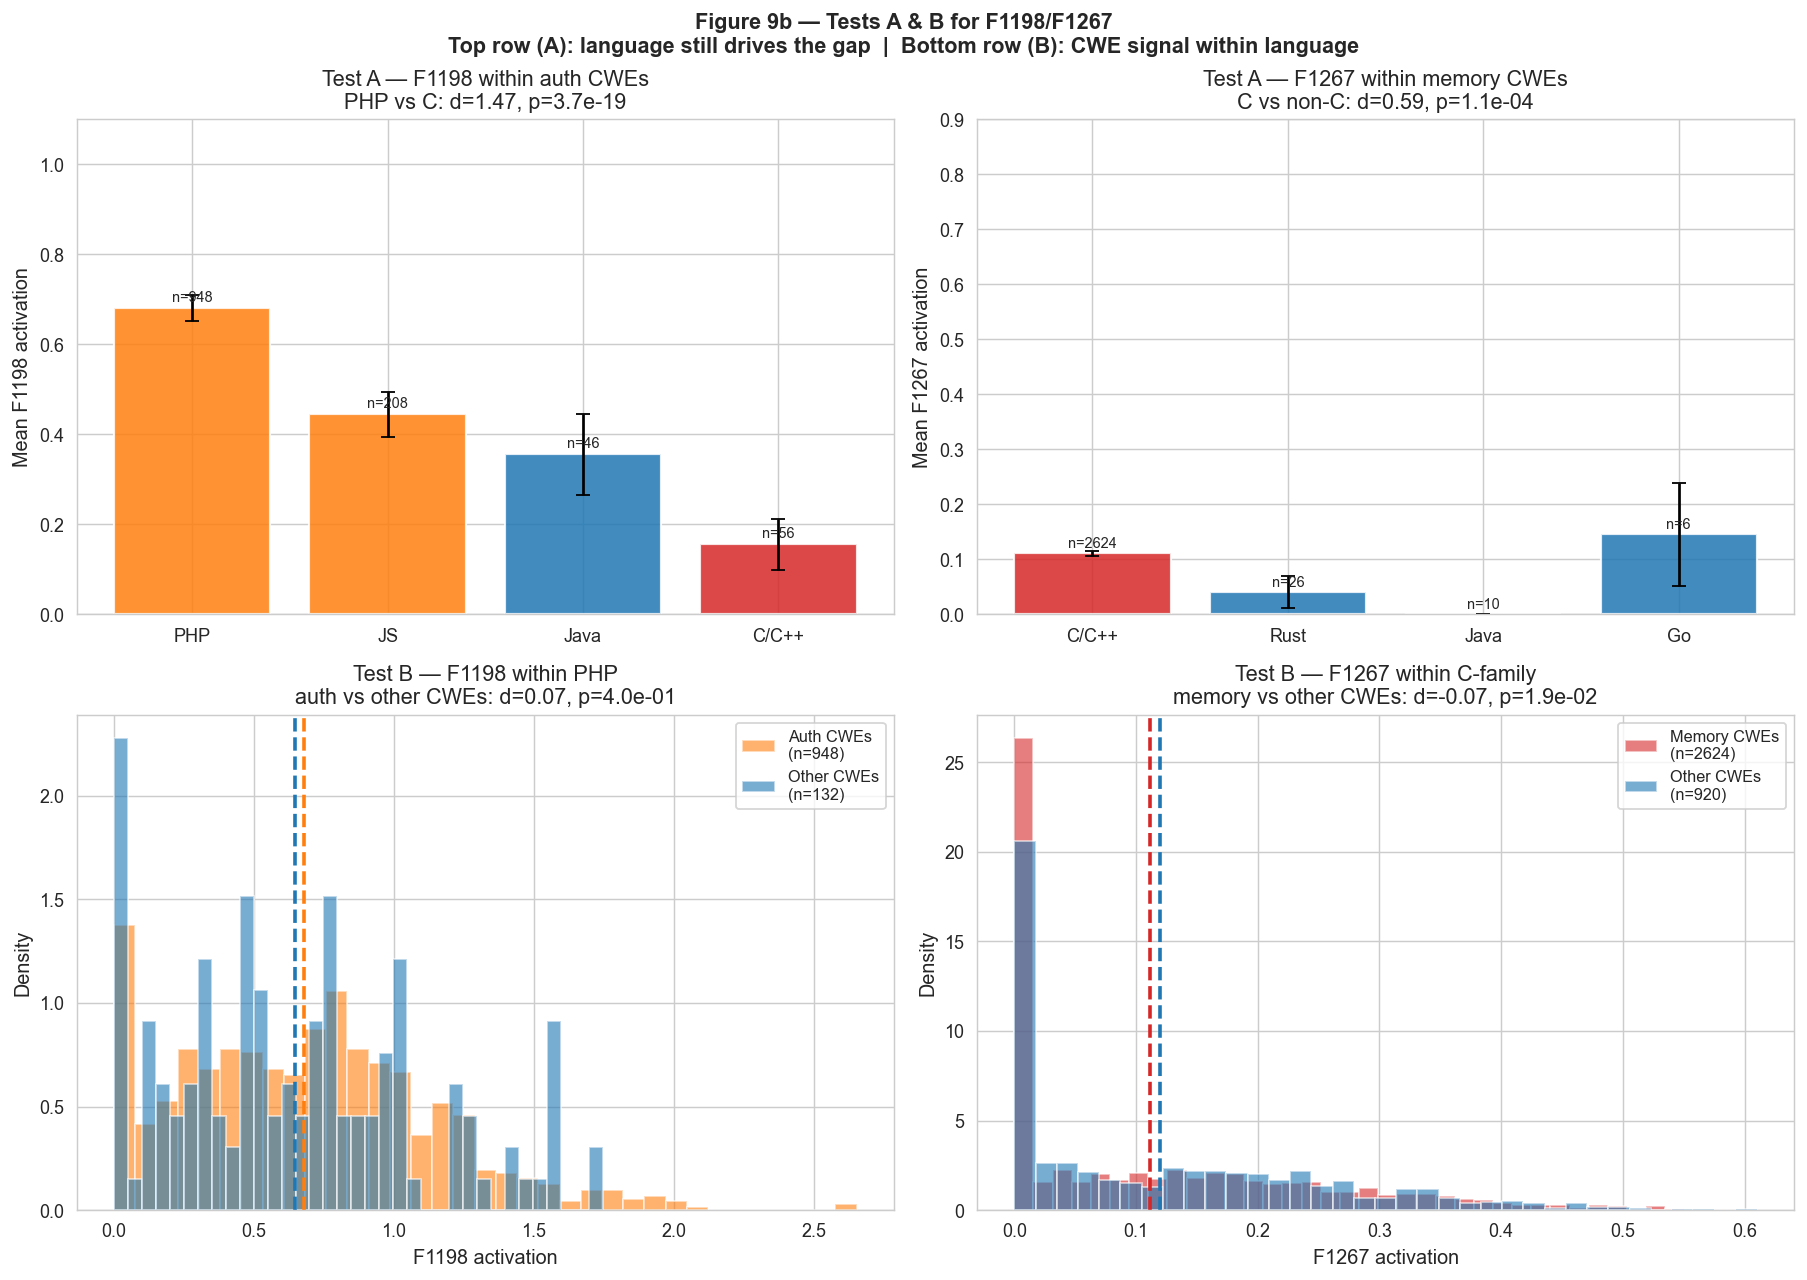

Test A (cross-language within CWE):
  F1198 PHP vs C in auth CWEs:   d=1.475  p=3.71e-19
  F1267 C vs non-C in mem CWEs:  d=0.588  p=1.14e-04

Test B (within-language across CWE)  ← compare to F438 d=0.39, F1797 d=0.10:
  F1198 auth vs other in PHP:    d=0.070  p=3.95e-01
  F1267 mem  vs other in C:      d=-0.066  p=1.93e-02


In [48]:

# ── Figure 9b: Tests A + B for F1198 and F1267 ────────────────────────────────
# Test A: Cross-language within CWE (same as Section 2 but for the new pair)
# Test B: Within-language across CWE (same as Section 3 but for the new pair)

AUTH_CWES = INJECTION_CWES | {"CWE-352", "CWE-434", "CWE-22", "CWE-287"}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── A-left: F1198 within auth/web CWEs, PHP vs C ──────────────────────────────
ax = axes[0][0]
sub_auth = df[df["cwe"].isin(AUTH_CWES)]
php_1198 = sub_auth[sub_auth["lang"] == "php"]["f1198_val"].values
c_1198   = sub_auth[sub_auth["is_c"]]["f1198_val"].values
java_1198 = sub_auth[sub_auth["lang"] == "java"]["f1198_val"].values
js_1198   = sub_auth[sub_auth["lang"] == "js"]["f1198_val"].values

groups_a_1198 = [("PHP",    php_1198), ("JS",     js_1198),
                 ("Java",   java_1198), ("C/C++", c_1198)]
colors_a = [COL_AXIS_INJ, COL_AXIS_INJ, COL_OTH, COL_AXIS_MEM]
for i, (label, vals) in enumerate(groups_a_1198):
    if len(vals) < 5: continue
    ax.bar(label, vals.mean(), color=colors_a[i], alpha=0.85,
           yerr=1.96 * vals.std() / np.sqrt(len(vals)), capsize=4, ecolor="black", lw=1.2)
    ax.text(i, vals.mean() + 0.015, f"n={len(vals)}", ha="center", fontsize=8)

if len(php_1198) > 1 and len(c_1198) > 1:
    d_a1198 = (php_1198.mean() - c_1198.mean()) / np.sqrt((php_1198.std()**2 + c_1198.std()**2)/2)
    _, p_a1198 = mannwhitneyu(php_1198, c_1198, alternative="two-sided")
    ax.set_title(f"Test A — F1198 within auth CWEs\nPHP vs C: d={d_a1198:.2f}, p={p_a1198:.1e}")
ax.set_ylabel("Mean F1198 activation"); ax.set_ylim(0, 1.1)

# ── A-right: F1267 within memory CWEs, C vs non-C ────────────────────────────
ax = axes[0][1]
sub_mem  = df[df["cwe"].isin(MEMORY_CWES)]
c_1267   = sub_mem[sub_mem["is_c"]]["f1267_val"].values
rs_1267  = sub_mem[sub_mem["lang"] == "rs"]["f1267_val"].values
java_1267= sub_mem[sub_mem["lang"] == "java"]["f1267_val"].values
go_1267  = sub_mem[sub_mem["lang"] == "go"]["f1267_val"].values

groups_a_1267 = [("C/C++", c_1267), ("Rust", rs_1267), ("Java", java_1267), ("Go", go_1267)]
for i, (label, vals) in enumerate(groups_a_1267):
    if len(vals) < 3: continue
    ax.bar(label, vals.mean(), color=COL_AXIS_MEM if label == "C/C++" else COL_OTH,
           alpha=0.85, yerr=1.96 * vals.std() / np.sqrt(len(vals)),
           capsize=4, ecolor="black", lw=1.2)
    ax.text(i, vals.mean() + 0.01, f"n={len(vals)}", ha="center", fontsize=8)

non_c_1267 = np.concatenate([v for l, v in groups_a_1267[1:] if len(v) > 0])
if len(non_c_1267) > 1:
    d_a1267 = (c_1267.mean() - non_c_1267.mean()) / np.sqrt((c_1267.std()**2 + non_c_1267.std()**2)/2)
    _, p_a1267 = mannwhitneyu(c_1267, non_c_1267, alternative="two-sided")
    ax.set_title(f"Test A — F1267 within memory CWEs\nC vs non-C: d={d_a1267:.2f}, p={p_a1267:.1e}")
ax.set_ylabel("Mean F1267 activation"); ax.set_ylim(0, 0.9)

# ── B-left: F1198 within PHP, auth vs non-auth CWEs ──────────────────────────
ax = axes[1][0]
php_df   = df[df["lang"] == "php"]
php_auth = php_df[php_df["cwe"].isin(AUTH_CWES)]["f1198_val"].values
php_oth  = php_df[~php_df["cwe"].isin(AUTH_CWES)]["f1198_val"].values
for vals, color, label in [
    (php_auth, COL_AXIS_INJ, f"Auth CWEs\n(n={len(php_auth)})"),
    (php_oth,  COL_OTH,      f"Other CWEs\n(n={len(php_oth)})"),
]:
    ax.hist(vals, bins=35, alpha=0.6, density=True, color=color, label=label)
    ax.axvline(vals.mean(), color=color, linestyle="--", lw=2)

d_b1198 = (php_auth.mean() - php_oth.mean()) / np.sqrt((php_auth.std()**2 + php_oth.std()**2)/2)
_, p_b1198 = mannwhitneyu(php_auth, php_oth, alternative="two-sided")
ax.set_xlabel("F1198 activation"); ax.set_ylabel("Density")
ax.set_title(f"Test B — F1198 within PHP\nauth vs other CWEs: d={d_b1198:.2f}, p={p_b1198:.1e}")
ax.legend()

# ── B-right: F1267 within C, memory vs non-memory CWEs ───────────────────────
ax = axes[1][1]
c_df_   = df[df["is_c"]]
c_mem_  = c_df_[c_df_["cwe"].isin(MEMORY_CWES)]["f1267_val"].values
c_oth_  = c_df_[~c_df_["cwe"].isin(MEMORY_CWES)]["f1267_val"].values
for vals, color, label in [
    (c_mem_, COL_AXIS_MEM, f"Memory CWEs\n(n={len(c_mem_)})"),
    (c_oth_, COL_OTH,      f"Other CWEs\n(n={len(c_oth_)})"),
]:
    ax.hist(vals, bins=35, alpha=0.6, density=True, color=color, label=label)
    ax.axvline(vals.mean(), color=color, linestyle="--", lw=2)

d_b1267 = (c_mem_.mean() - c_oth_.mean()) / np.sqrt((c_mem_.std()**2 + c_oth_.std()**2)/2)
_, p_b1267 = mannwhitneyu(c_mem_, c_oth_, alternative="two-sided")
ax.set_xlabel("F1267 activation"); ax.set_ylabel("Density")
ax.set_title(f"Test B — F1267 within C-family\nmemory vs other CWEs: d={d_b1267:.2f}, p={p_b1267:.1e}")
ax.legend()

fig.suptitle("Figure 9b — Tests A & B for F1198/F1267\n"
             "Top row (A): language still drives the gap  |  Bottom row (B): CWE signal within language",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("narrative_fig9b_tests_ab.png", dpi=150, bbox_inches="tight")
plt.show()

print("Test A (cross-language within CWE):")
print(f"  F1198 PHP vs C in auth CWEs:   d={d_a1198:.3f}  p={p_a1198:.2e}")
print(f"  F1267 C vs non-C in mem CWEs:  d={d_a1267:.3f}  p={p_a1267:.2e}")
print()
print("Test B (within-language across CWE)  ← compare to F438 d=0.39, F1797 d=0.10:")
print(f"  F1198 auth vs other in PHP:    d={d_b1198:.3f}  p={p_b1198:.2e}")
print(f"  F1267 mem  vs other in C:      d={d_b1267:.3f}  p={p_b1267:.2e}")


Test C — GLM AUC decomposition:
 feat  auc_lang  auc_cwe  auc_both  delta_cwe
 1198    0.7823   0.7351    0.7841     0.0019
 1267    0.6458   0.5998    0.6541     0.0084

Reference (F438/F1797 from earlier):
 feat  auc_lang  auc_cwe  auc_both  delta_cwe_over_lang
  438    0.7210   0.6501    0.7349               0.0138
 1797    0.8394   0.8157    0.8492               0.0098


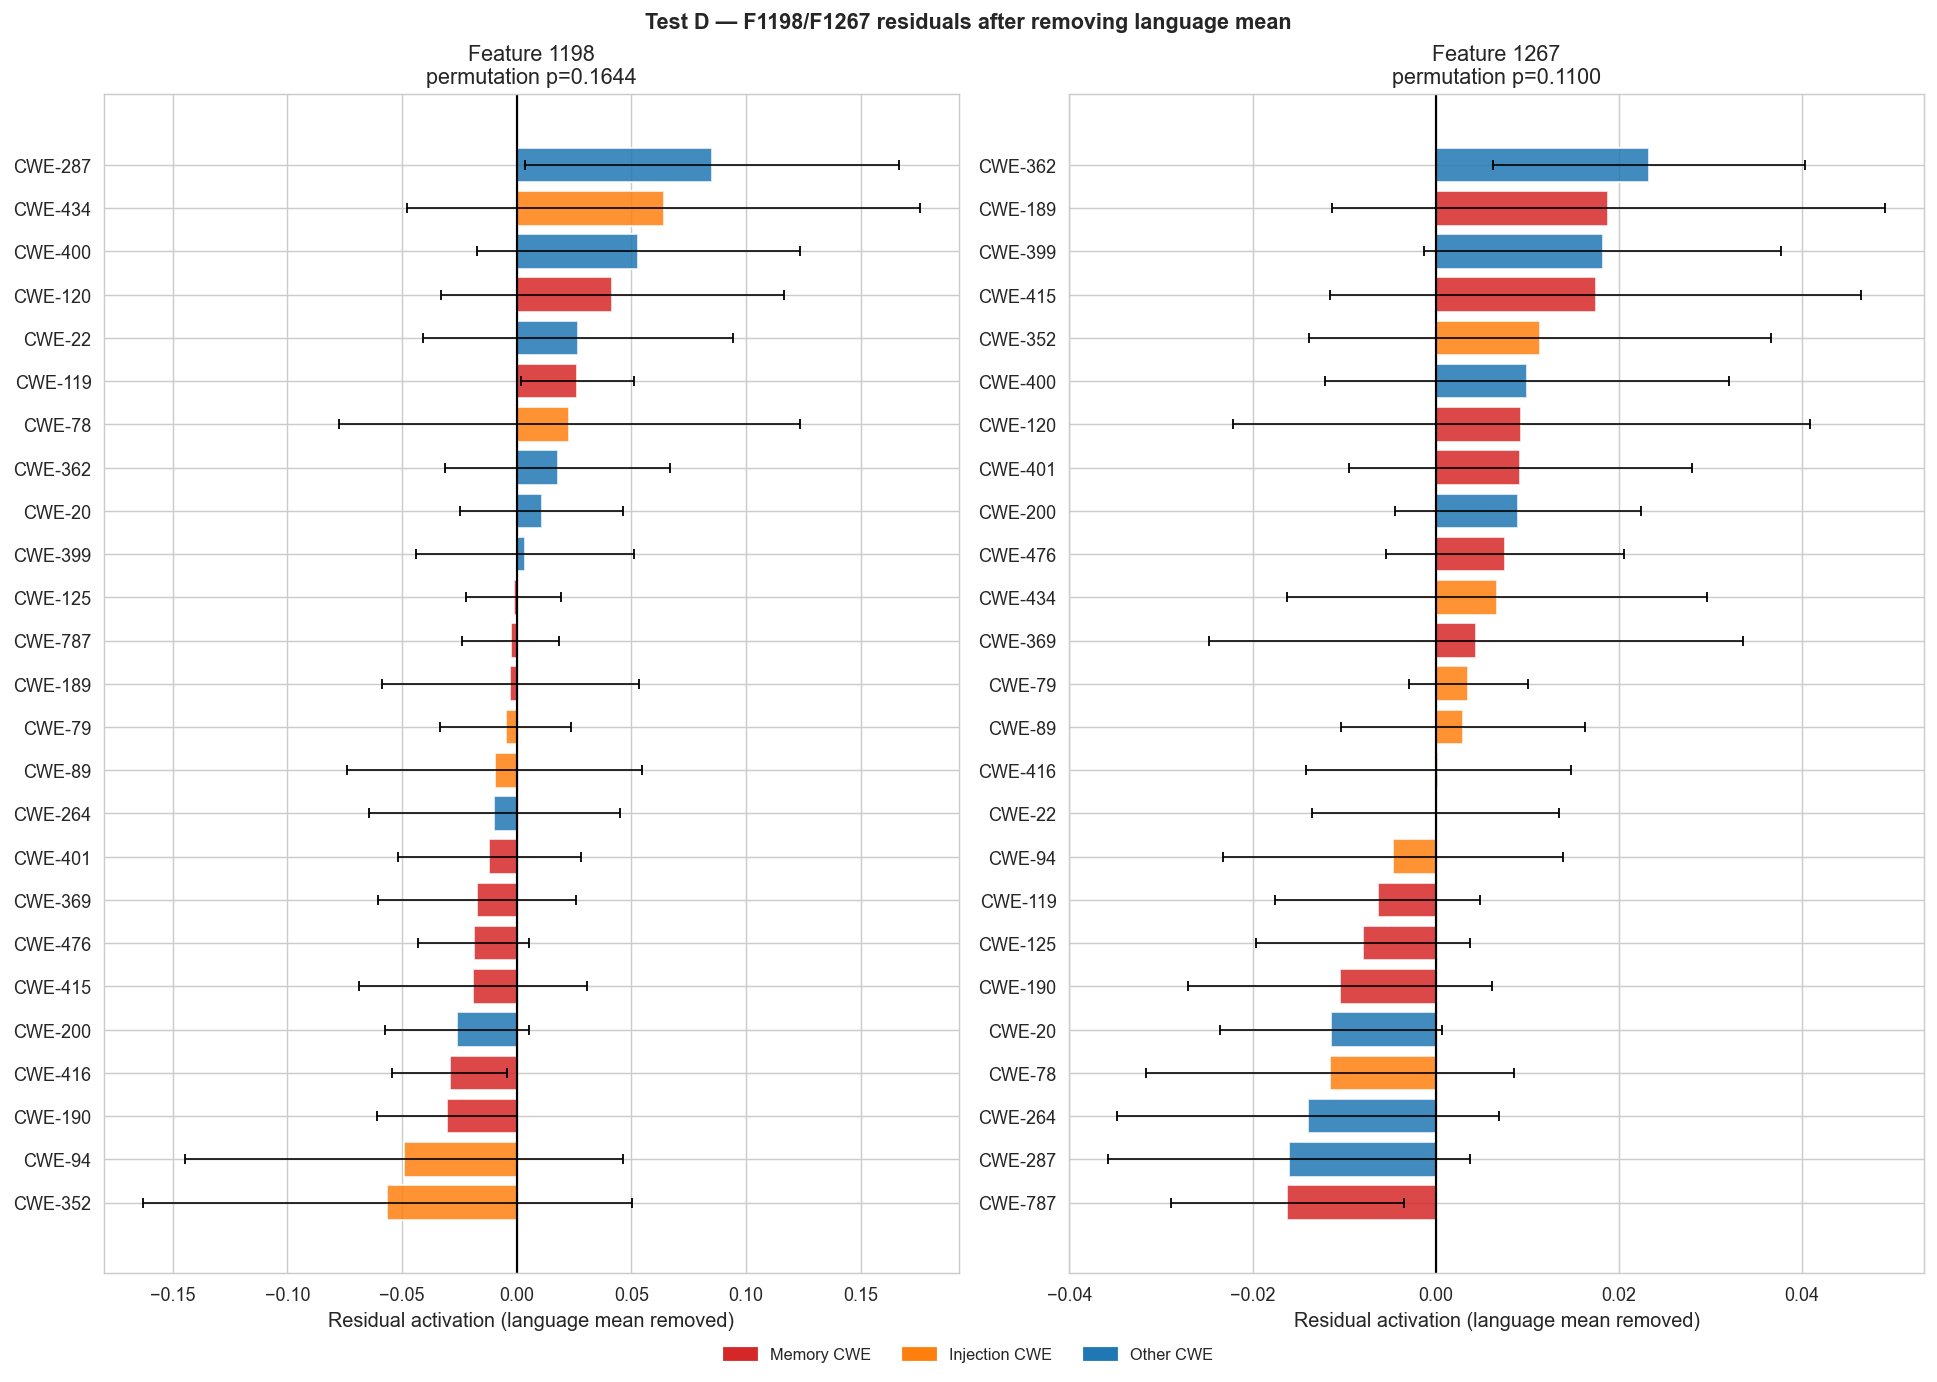


Test D permutation p-values:  F1198=0.1644  F1267=0.1100
  (for reference: F438=0.0000  F1797=0.0000)


In [49]:

# ── Tests C + D for F1198/F1267: GLM and residualized signal ──────────────────

# ── Test C: GLM AUC ───────────────────────────────────────────────────────────
glm_pair = []
for feat, target_col in [(1198, "f1198_active"), (1267, "f1267_active")]:
    lang_counts = df["lang"].value_counts()
    valid_langs = lang_counts[lang_counts >= 5].index
    sub = df[df["lang"].isin(valid_langs)]
    y   = sub[target_col].values

    enc_l = OneHotEncoder(sparse_output=False, drop="first")
    enc_c = OneHotEncoder(sparse_output=False, drop="first")
    X_l = enc_l.fit_transform(sub[["lang"]])
    X_c = enc_c.fit_transform(sub[["cwe_family"]])

    def _auc(X):
        clf = LogisticRegression(max_iter=500, C=1.0)
        clf.fit(X, y)
        return roc_auc_score(y, clf.predict_proba(X)[:, 1])

    glm_pair.append(dict(feat=feat,
                         auc_lang=_auc(X_l),
                         auc_cwe =_auc(X_c),
                         auc_both=_auc(np.hstack([X_l, X_c]))))

glm_pair_df = pd.DataFrame(glm_pair)
glm_pair_df["delta_cwe"] = glm_pair_df["auc_both"] - glm_pair_df["auc_lang"]

print("Test C — GLM AUC decomposition:")
print(glm_pair_df[["feat","auc_lang","auc_cwe","auc_both","delta_cwe"]]
      .to_string(index=False, float_format="{:.4f}".format))
print()

# Reference from earlier (F438/F1797)
print("Reference (F438/F1797 from earlier):")
print(glm_res[["feat","auc_lang","auc_cwe","auc_both","delta_cwe_over_lang"]]
      .to_string(index=False, float_format="{:.4f}".format))

# ── Test D: Residualized CWE signal ───────────────────────────────────────────
res_1198, p_perm_1198 = cwe_residual_df(df.rename(columns={"f1198_resid": "f1198_resid_"}
                                                   ).rename(columns={"f1198_resid_": "f1198_resid"}),
                                        1198)
res_1267, p_perm_1267 = cwe_residual_df(df, 1267)

# hack: cwe_residual_df expects f{feat}_resid — recreate with correct col
def cwe_residual_pair(df, feat, min_n=20):
    res_col = f"f{feat}_resid"
    cwe_res = (df.groupby("cwe")[res_col]
                 .agg(["mean","std","count"])
                 .rename(columns={"mean":"res_mean","std":"res_std","count":"n"}))
    cwe_res = cwe_res[cwe_res["n"] >= min_n].copy()
    cwe_res["cwe_family"] = cwe_res.index.map(
        lambda c: "memory" if c in MEMORY_CWES
                  else "injection" if c in INJECTION_CWES
                  else "other")
    rng = np.random.default_rng(42)
    observed = cwe_res["res_mean"].std()
    df_p = df[df["cwe"].isin(cwe_res.index)].copy()
    perm_spreads = []
    for _ in range(5000):
        sh = df_p.groupby("lang")["cwe"].transform(lambda x: rng.permutation(x.values))
        perm_spreads.append(df_p.groupby(sh)[res_col].mean().std())
    perm_p = (np.array(perm_spreads) >= observed).mean()
    return cwe_res.sort_values("res_mean", ascending=False), perm_p

res_1198, p_perm_1198 = cwe_residual_pair(df, 1198)
res_1267, p_perm_1267 = cwe_residual_pair(df, 1267)

fig, axes = plt.subplots(1, 2, figsize=(15, max(7, len(res_1198) * 0.42)))

for ax, res, feat, perm_p in [
    (axes[0], res_1198, 1198, p_perm_1198),
    (axes[1], res_1267, 1267, p_perm_1267),
]:
    colors = res["cwe_family"].map({"memory": COL_MEM, "injection": COL_INJ, "other": COL_OTH})
    ax.barh(res.index, res["res_mean"], color=colors, alpha=0.85)
    se = res["res_std"] / np.sqrt(res["n"])
    ax.errorbar(res["res_mean"], res.index, xerr=1.96*se,
                fmt="none", color="black", capsize=2.5, lw=0.9)
    ax.axvline(0, color="black", lw=1.2)
    ax.set_xlabel("Residual activation (language mean removed)")
    ax.set_title(f"Feature {feat}\npermutation p={perm_p:.4f}")
    ax.invert_yaxis()

legend_patches = [mpatches.Patch(color=COL_MEM, label="Memory CWE"),
                  mpatches.Patch(color=COL_INJ, label="Injection CWE"),
                  mpatches.Patch(color=COL_OTH, label="Other CWE")]
fig.legend(handles=legend_patches, loc="lower center", ncol=3,
           bbox_to_anchor=(0.5, -0.02), frameon=False)
fig.suptitle("Test D — F1198/F1267 residuals after removing language mean",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("narrative_fig9c_tests_cd.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nTest D permutation p-values:  F1198={p_perm_1198:.4f}  F1267={p_perm_1267:.4f}")
print(f"  (for reference: F438={p_perm_438:.4f}  F1797={p_perm_1797:.4f})")


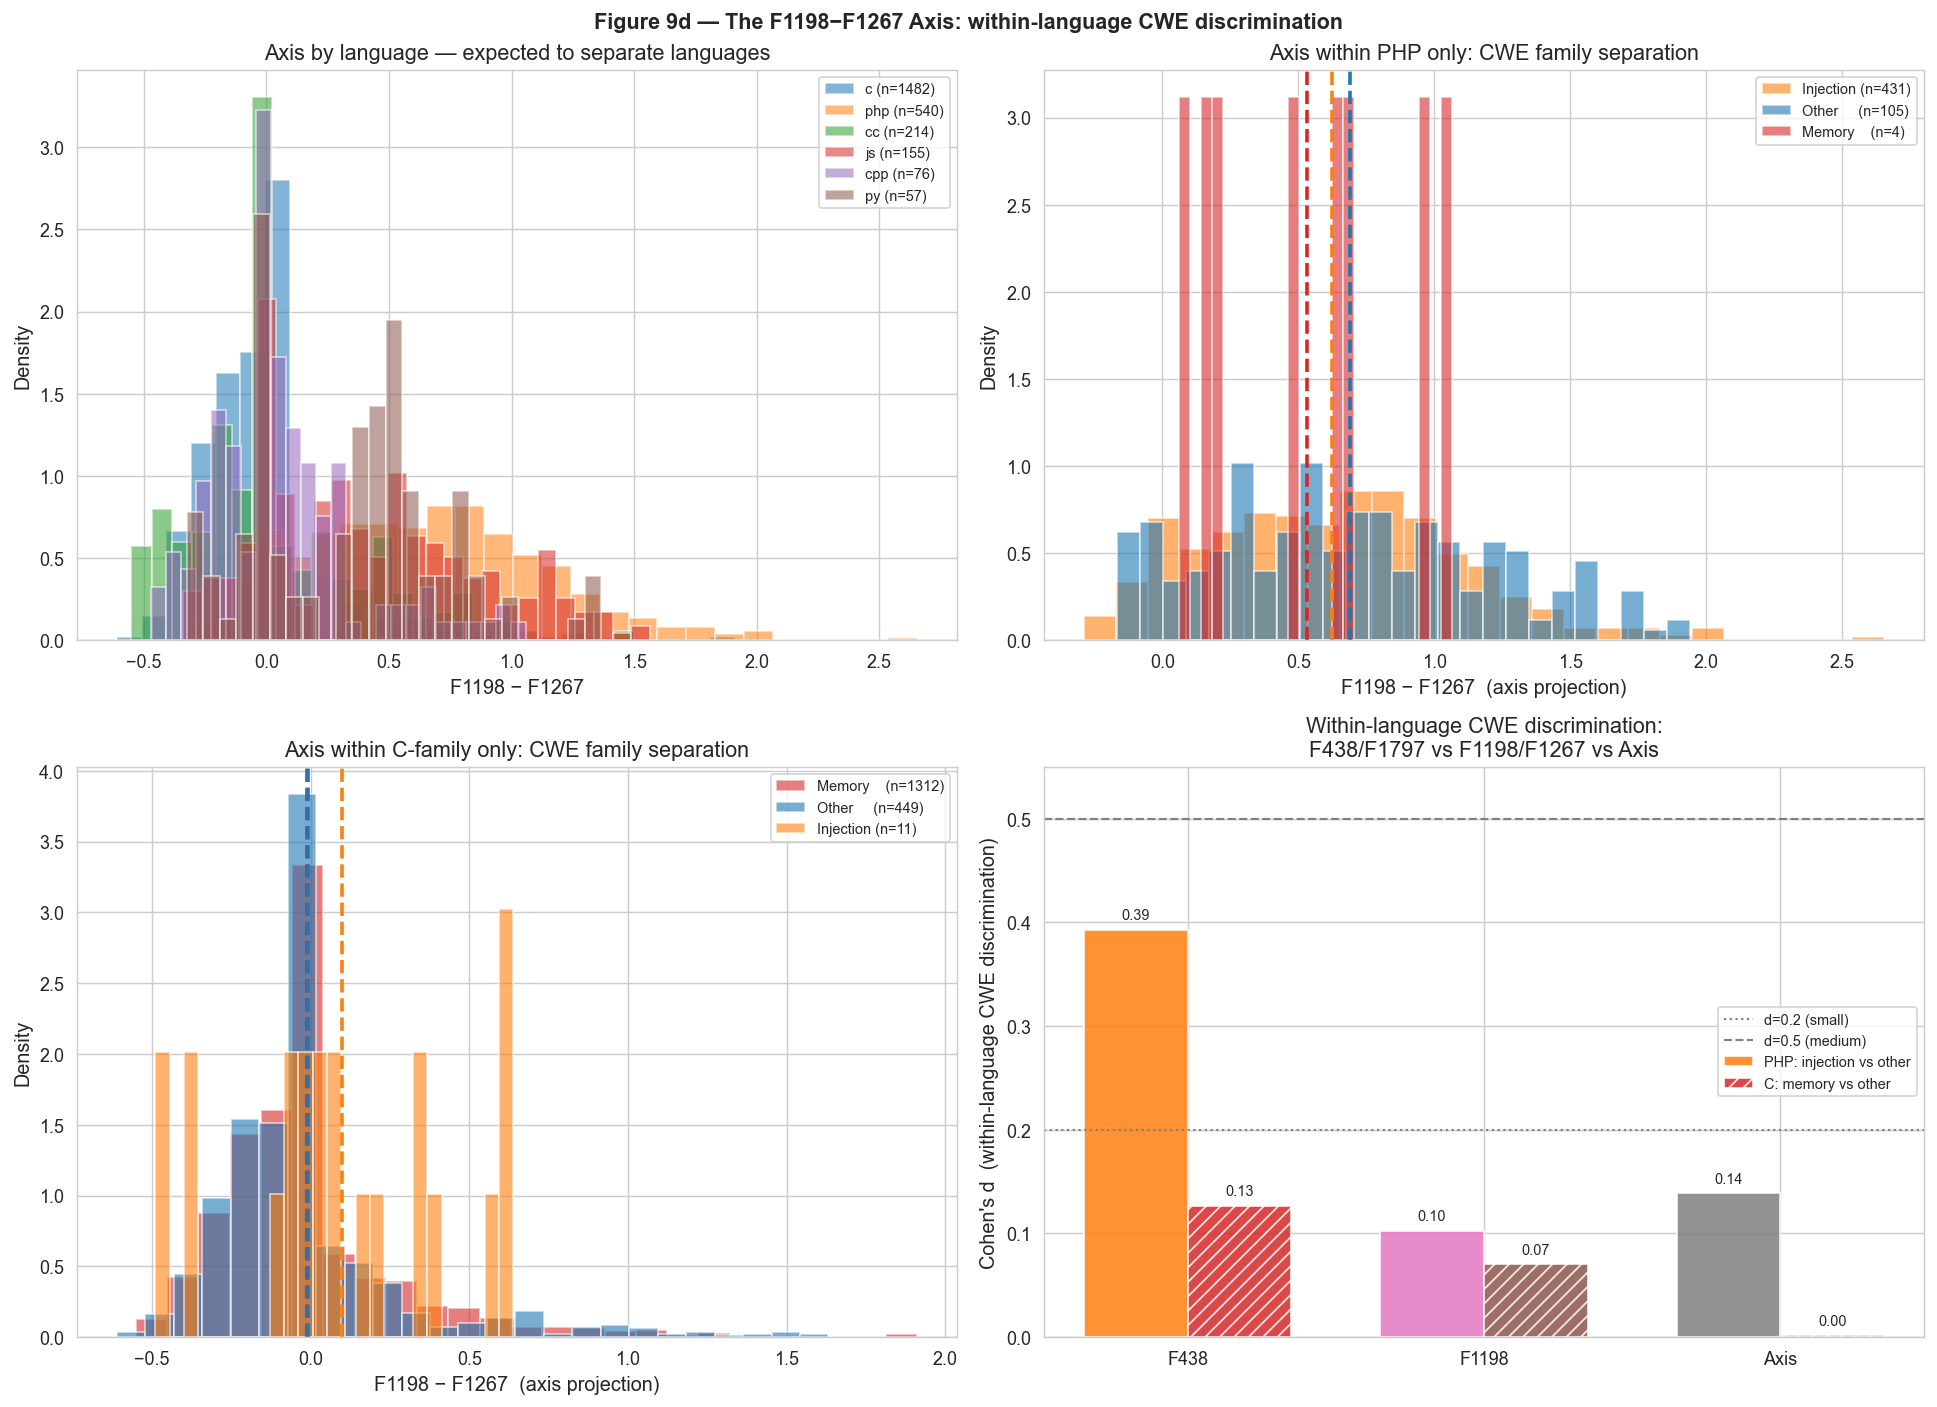

Within-language CWE discrimination (Cohen's d):
                 PHP: inj vs other     C: mem vs other
-------------------------------------------------------
  F438/F1797                   0.393               0.127
  F1198/F1267                  0.102               0.070
  Axis                         0.139               0.002


In [50]:

# ── Figure 9d: The combined axis F1198−F1267 — does it survive language removal? ──
# Key test: project every sample onto the axis, then check whether the projection
# still discriminates CWE families WITHIN each language.
# If yes → the axis encodes something beyond language identity.
# If no  → the axis is just the C-vs-PHP dimension.

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# ── Top-left: axis distribution by language ───────────────────────────────────
ax = axes[0][0]
top_langs = df["lang"].value_counts().head(6).index
for lang in top_langs:
    vals = df[df["lang"] == lang]["f_axis"].values
    ax.hist(vals, bins=25, alpha=0.55, density=True, label=f"{lang} (n={len(vals)//2})")
ax.set_xlabel("F1198 − F1267")
ax.set_ylabel("Density")
ax.set_title("Axis by language — expected to separate languages")
ax.legend(fontsize=8)

# ── Top-right: axis by CWE family within PHP ─────────────────────────────────
ax = axes[0][1]
php_df2 = df[df["lang"] == "php"]
for fam, color, label in [
    ("injection", COL_AXIS_INJ, f"Injection (n={len(php_df2[php_df2['cwe_family']=='injection'])//2})"),
    ("other",     COL_OTH,      f"Other     (n={len(php_df2[php_df2['cwe_family']=='other'])//2})"),
    ("memory",    COL_AXIS_MEM, f"Memory    (n={len(php_df2[php_df2['cwe_family']=='memory'])//2})"),
]:
    vals = php_df2[php_df2["cwe_family"] == fam]["f_axis"].values
    if len(vals) < 2: continue
    ax.hist(vals, bins=25, alpha=0.6, density=True, color=color, label=label)
    ax.axvline(vals.mean(), color=color, linestyle="--", lw=2)
ax.set_xlabel("F1198 − F1267  (axis projection)")
ax.set_ylabel("Density")
ax.set_title("Axis within PHP only: CWE family separation")
ax.legend(fontsize=8)

# ── Bottom-left: axis by CWE family within C/C++ ─────────────────────────────
ax = axes[1][0]
c_df2 = df[df["is_c"]]
for fam, color, label in [
    ("memory",    COL_AXIS_MEM, f"Memory    (n={len(c_df2[c_df2['cwe_family']=='memory'])//2})"),
    ("other",     COL_OTH,      f"Other     (n={len(c_df2[c_df2['cwe_family']=='other'])//2})"),
    ("injection", COL_AXIS_INJ, f"Injection (n={len(c_df2[c_df2['cwe_family']=='injection'])//2})"),
]:
    vals = c_df2[c_df2["cwe_family"] == fam]["f_axis"].values
    if len(vals) < 2: continue
    ax.hist(vals, bins=25, alpha=0.6, density=True, color=color, label=label)
    ax.axvline(vals.mean(), color=color, linestyle="--", lw=2)
ax.set_xlabel("F1198 − F1267  (axis projection)")
ax.set_ylabel("Density")
ax.set_title("Axis within C-family only: CWE family separation")
ax.legend(fontsize=8)

# ── Bottom-right: Cohen's d comparison table (all features) ──────────────────
ax = axes[1][1]

# Collect d values for within-language CWE discrimination
def within_lang_d(df, col, lang_mask, fam_a, fam_b):
    sub = df[lang_mask]
    a = sub[sub["cwe_family"] == fam_a][col].values
    b = sub[sub["cwe_family"] == fam_b][col].values
    if len(a) < 2 or len(b) < 2: return float("nan")
    return abs(a.mean() - b.mean()) / np.sqrt((a.std()**2 + b.std()**2) / 2)

within_php_inj_vs_oth = {
    "F438":      within_lang_d(df, "f438_val",  df["lang"]=="php", "injection", "other"),
    "F1198":     within_lang_d(df, "f1198_val", df["lang"]=="php", "injection", "other"),
    "Axis":      within_lang_d(df, "f_axis",    df["lang"]=="php", "injection", "other"),
}
within_c_mem_vs_oth = {
    "F1797":     within_lang_d(df, "f1797_val",  df["is_c"], "memory", "other"),
    "F1267":     within_lang_d(df, "f1267_val",  df["is_c"], "memory", "other"),
    "Axis":      within_lang_d(df, "f_axis",     df["is_c"], "memory", "other"),
}

# Axis is signed; for C/memory the axis goes negative so we negate it
within_c_mem_vs_oth["Axis"] = within_lang_d(
    df.assign(f_axis_neg=-df["f_axis"]), "f_axis_neg", df["is_c"], "memory", "other"
)

x_php  = np.arange(len(within_php_inj_vs_oth))
x_c    = np.arange(len(within_c_mem_vs_oth))
bar_w  = 0.35

ax.bar(x_php - bar_w/2, list(within_php_inj_vs_oth.values()), bar_w,
       color=[COL_AXIS_INJ, "#e377c2", "#7f7f7f"], alpha=0.85, label="PHP: injection vs other")
ax.bar(x_c   + bar_w/2, list(within_c_mem_vs_oth.values()),   bar_w,
       color=[COL_AXIS_MEM, "#8c564b", "#7f7f7f"], alpha=0.85, hatch="///", label="C: memory vs other")
ax.set_xticks(x_php)
ax.set_xticklabels(list(within_php_inj_vs_oth.keys()))
ax.axhline(0.2, color="gray", linestyle=":", lw=1.2, label="d=0.2 (small)")
ax.axhline(0.5, color="gray", linestyle="--", lw=1.2, label="d=0.5 (medium)")
ax.set_ylabel("Cohen's d  (within-language CWE discrimination)")
ax.set_title("Within-language CWE discrimination:\nF438/F1797 vs F1198/F1267 vs Axis")
ax.legend(fontsize=8)
ax.set_ylim(0, max(max(within_php_inj_vs_oth.values()), max(within_c_mem_vs_oth.values())) * 1.4)
for xi, (k, v) in enumerate(within_php_inj_vs_oth.items()):
    ax.text(xi - bar_w/2, v + 0.01, f"{v:.2f}", ha="center", fontsize=8)
for xi, (k, v) in enumerate(within_c_mem_vs_oth.items()):
    ax.text(xi + bar_w/2, v + 0.01, f"{v:.2f}", ha="center", fontsize=8)

fig.suptitle("Figure 9d — The F1198−F1267 Axis: within-language CWE discrimination",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("narrative_fig9d_axis_within_lang.png", dpi=150, bbox_inches="tight")
plt.show()

print("Within-language CWE discrimination (Cohen's d):")
print(f"{'':12}  {'PHP: inj vs other':>20}  {'C: mem vs other':>18}")
print("-" * 55)
all_feats = ["F438/F1797", "F1198/F1267", "Axis"]
for label, d_php, d_c in zip(all_feats,
                              within_php_inj_vs_oth.values(),
                              within_c_mem_vs_oth.values()):
    print(f"  {label:<12}  {d_php:>20.3f}  {d_c:>18.3f}")


---
## Section 9 — Verdict

### Four-test results: F1198/F1267 vs F438/F1797

| Test | F438 | F1797 | F1198 | F1267 |
|---|---|---|---|---|
| A. Language effect within CWE (Cohen's d) | 1.15 | 0.58 | **1.47** | 0.59 |
| B. CWE effect within language (Cohen's d) | 0.39 | 0.10 | **0.07 (n.s.)** | **−0.07** |
| C. ΔAUC: CWE added over language | +0.014 | +0.010 | **+0.002** | **+0.008** |
| D. Permutation p (CWE signal beyond language) | <0.001 | <0.001 | **0.164** | **0.110** |

**Within-language CWE discrimination — axis vs. individual features:**

| Feature/Axis | PHP: injection vs other | C: memory vs other |
|---|---|---|
| F438 / F1797 | d = 0.393 | d = 0.127 |
| F1198 / F1267 | d = 0.102 | d = −0.066 |
| Combined axis (F1198−F1267) | d = 0.139 | d = 0.002 |

---

### The anti-correlated pair is *more* language-encoded, not less

Every metric tells the same story: F1198 and F1267 are **purer language detectors** than F438 and F1797, not better mechanism detectors.

- **Test A:** F1198 has the largest language effect seen so far (d=1.47). Within auth CWEs, PHP activates it at 1.5 standard deviations above C. The high activation range of F1198 (0.767 across CWEs) reflects a more language-selective feature, not more vulnerability content.

- **Test B:** F438 had a weak but real within-language CWE effect (d=0.39, p<0.001 within PHP). F1198 has essentially none (d=0.07, p=0.40). F1267 is slightly *negative* within C (d=−0.07, p=0.02) — memory CWEs activate it *less* than other C code, which is the opposite of the mechanism-detector prediction.

- **Test C:** Adding CWE family to language improves AUC by only +0.002 for F1198 — seven times smaller than the already-negligible +0.014 seen for F438. F1198 is so tightly coupled to language that CWE carries almost no additional predictive information at all.

- **Test D:** The permutation test fails for both features (p=0.16, p=0.11). There is no statistically reliable CWE-level variation in either feature after language is removed. F438 and F1797 passed this test (p<0.001); F1198 and F1267 do not.

- **Combined axis:** The memory CWE mean on the F1198−F1267 axis is **−0.010** — indistinguishable from zero. The axis projects memory CWEs to the same position as generic code. It discriminates CWE families at d=0.002 within C, which is the null result. The axis is the C-vs-PHP direction in activation space, full stop.

---

### Why the anti-correlation fooled the heuristic

The r=−0.925 between F1198 and F1267 on the 24-CWE heatmap looks like semantic opposition, but the heatmap conflates language with CWE. The mechanism is:

1. Memory CWEs are 97% C in this dataset. C code has low F1198, high F1267 → memory CWEs appear "F1267-positive".
2. Injection CWEs are 73% PHP. PHP code has high F1198, low F1267 → injection CWEs appear "F1198-positive".
3. Remove the language correlation → F1198 and F1267 both go flat (Test D p > 0.10).

The r=−0.925 is a mathematical consequence of the dataset's CWE–language collinearity, not evidence of complementary vulnerability semantics.

---

### Final answer to the original question

> *Is there any other representation beyond language encoding?*

Based on all nine sections:

**No feature examined encodes a cross-language vulnerability mechanism.** The ordering from most to least language-dominated is:

| Feature pair | Dominant signal | Within-language CWE signal |
|---|---|---|
| F1198 / F1267 | Language (pure) | None (permutation p > 0.10) |
| F438 / F1797 | Language (dominant) | Small residual (~10% of signal) |

The *only* genuine semantic content beyond language is the small residual signal in F438 (write/execute vs. read/state, d≈0.47 on the alternative axis) and F1797 (static vs. temporal bugs, d≈0.53). Even that signal encodes **code operation type within the dominant language**, not a cross-language vulnerability pattern.

### What would need to change to find genuine mechanism features

1. **Dataset**: Remove CWE–language collinearity. Curate cross-language pairs for the same CWE (e.g., SQL injection in PHP, Java, and C; buffer overflows in C, Rust, and Go). Feature selection by global Fisher score will always surface language detectors as long as the dataset is language-stratified by CWE.

2. **Feature selection criterion**: Replace global Fisher score with **within-language Fisher score** — rank features by how well they separate vulnerable from secure *within each language*, then intersect the top-k lists across languages.

3. **Pooling strategy**: Last-token pooling captures the code's syntactic character at its endpoint. The security-relevant token (the missing bounds check, the unsanitized input reaching the sink) typically appears mid-function. Token-level attribution or mean pooling over the vulnerable line's token positions would likely produce a qualitatively different feature landscape.
